<a href="https://colab.research.google.com/github/EnasF/Applying-XAI-for-Demand-Forecasting-and-Pricing-Decision-in-Supply-Chain/blob/main/Capstone_Project__CatBoost_SHAP_PDP_LIME_Price_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CatBoost Model

This notebook Contains **CatBoostRegressor** Model .

 steps:
1. Load processed samples A, B, and C
2. Prepare features
3. Apply time-based train/validation/test split
4. Train CatBoost model
5. Evaluate validation and final test performance
6. Price optimization simulation and Evaluation
7. XAI Analysis and Evaluation

In [ ]:
# =====================================================
# 1. Install Required Library
# =====================================================

!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.5 MB/s eta 0:00:00


In [ ]:
# =====================================================
# 2. Import Libraries
# =====================================================

import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# =====================================================
# 3. Mount Google Drive
# =====================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =====================================================
# 4. User Settings
# =====================================================

TARGET_COL = 'demand'
RANDOM_STATE = 42

In [ ]:
# =====================================================
# 5. Load Data
# =====================================================

# Update these paths based on your Google Drive location

df_A = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_A.csv',
    parse_dates=['date']
)

df_B = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_B.csv',
    parse_dates=['date']
)

df_C = pd.read_csv(
    '/content/drive/MyDrive/Graduation Project Data/processed_data_C.csv',
    parse_dates=['date']
)

print('Sample A shape:', df_A.shape)
print('Sample B shape:', df_B.shape)
print('Sample C shape:', df_C.shape)

Sample A shape: (737580, 49)
Sample B shape: (737580, 49)
Sample C shape: (737580, 49)


In [ ]:
# =====================================================
# 6. Feature Selection Function
# =====================================================

def prepare_features(df, target_col='demand', exclude_cols=None):
    """
    Select model input features.

    The function removes columns that should not be used as predictors:
    - target column
    - date column
    - ID/sequence columns
    """

    if exclude_cols is None:
        exclude_cols = ['date', 'id', 'd', target_col]

    exclude_cols = [col for col in exclude_cols if col in df.columns]
    feature_cols = [col for col in df.columns if col not in exclude_cols]

    print('Excluded columns:', exclude_cols)
    print('Number of selected features:', len(feature_cols))
    print('Selected features:')
    print(feature_cols)

    return feature_cols

In [ ]:
# =====================================================
# 7. Time-Based Split Function
# =====================================================

def time_based_split(df, target_col='demand', feature_cols=None, date_col='date'):
    """
    Split the data by time order.

    Split ratio:
    - 70% training
    - 20% validation
    - 10% testing
    """

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    sort_cols = [date_col]
    for col in ['store_id', 'item_id']:
        if col in df.columns:
            sort_cols.append(col)

    df = df.sort_values(sort_cols).reset_index(drop=True)

    unique_dates = np.array(sorted(df[date_col].unique()))
    n_dates = len(unique_dates)

    train_end_idx = int(n_dates * 0.70)
    val_end_idx = int(n_dates * 0.90)

    train_dates = unique_dates[:train_end_idx]
    val_dates = unique_dates[train_end_idx:val_end_idx]
    test_dates = unique_dates[val_end_idx:]

    train_df = df[df[date_col].isin(train_dates)].copy()
    val_df = df[df[date_col].isin(val_dates)].copy()
    test_df = df[df[date_col].isin(test_dates)].copy()

    X_train = train_df[feature_cols].copy()
    y_train = train_df[target_col].copy()

    X_val = val_df[feature_cols].copy()
    y_val = val_df[target_col].copy()

    X_test = test_df[feature_cols].copy()
    y_test = test_df[target_col].copy()

    print('Train shape:', X_train.shape)
    print('Validation shape:', X_val.shape)
    print('Test shape:', X_test.shape)

    return train_df, val_df, test_df, X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
# =====================================================
# 8. Prepare CatBoost Inputs
# =====================================================

def prepare_catboost_inputs(X_train, X_val=None, X_test=None):
    """
    Prepare categorical columns for CatBoost.

    CatBoost accepts categorical columns directly.
    We only convert categorical columns to string and fill missing values.
    """

    datasets = [X_train]
    if X_val is not None:
        datasets.append(X_val)
    if X_test is not None:
        datasets.append(X_test)

    cat_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

    for data in datasets:
        for col in cat_features:
            data[col] = data[col].astype(str).fillna('missing')

    print('Categorical features used by CatBoost:')
    print(cat_features)

    if X_val is not None and X_test is not None:
        return X_train, X_val, X_test, cat_features
    elif X_val is not None:
        return X_train, X_val, cat_features
    else:
        return X_train, cat_features

In [ ]:
# =====================================================
# 9. Evaluation Function
# =====================================================

def evaluate_model(y_true, y_pred):
    """Calculate common regression metrics."""

    y_pred = np.clip(y_pred, 0, None)

    metrics = {
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

    return metrics

In [ ]:
# =====================================================
# 10. CatBoost Training Function
# =====================================================

def train_catboost_model(X_train, y_train, X_val, y_val, cat_features, random_state=42):

    #Train a CatBoost regression model


    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=random_state,
        verbose=100
    )

    model.fit(
        X_train,
        y_train,
        cat_features=cat_features,
        eval_set=(X_val, y_val),
        use_best_model=True,
        early_stopping_rounds=50
    )

    val_pred = model.predict(X_val)
    val_metrics = evaluate_model(y_val, val_pred)

    print('Validation Metrics:')
    print(val_metrics)

    return model, val_metrics

In [ ]:
# =====================================================
# 11. Final Training and Test Evaluation Function
# =====================================================

def train_final_catboost_and_evaluate(
    train_df,
    val_df,
    X_test,
    y_test,
    feature_cols,
    target_col,
    random_state=42
):
    """
    Train final CatBoost model using train + validation data,
    then evaluate on the test set.
    """

    trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

    X_trainval = trainval_df[feature_cols].copy()
    y_trainval = trainval_df[target_col].copy()

    X_trainval, X_test, cat_features = prepare_catboost_inputs(X_trainval, X_test)

    final_model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=random_state,
        verbose=100
    )

    final_model.fit(
        X_trainval,
        y_trainval,
        cat_features=cat_features
    )

    test_pred = final_model.predict(X_test)
    test_metrics = evaluate_model(y_test, test_pred)

    print('Final Test Metrics:')
    print(test_metrics)

    return final_model, test_metrics

In [ ]:
# =====================================================
# 12. Full CatBoost Pipeline for One Sample
# =====================================================

def run_catboost_pipeline(df, sample_name='Sample', target_col='demand', random_state=42):
    """
    Run CatBoost pipeline for one sample.
    """

    print(f'==================== Running {sample_name} ====================')

    feature_cols = prepare_features(df, target_col=target_col)

    train_df, val_df, test_df, X_train, y_train, X_val, y_val, X_test, y_test = time_based_split(
        df=df,
        target_col=target_col,
        feature_cols=feature_cols
    )

    X_train, X_val, X_test, cat_features = prepare_catboost_inputs(X_train, X_val, X_test)

    model, val_metrics = train_catboost_model(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        cat_features=cat_features,
        random_state=random_state
    )

    final_model, test_metrics = train_final_catboost_and_evaluate(
        train_df=train_df,
        val_df=val_df,
        X_test=X_test,
        y_test=y_test,
        feature_cols=feature_cols,
        target_col=target_col,
        random_state=random_state
    )

    return {
        'sample_name': sample_name,
        'feature_cols': feature_cols,
        'cat_features': cat_features,
        'validation_metrics': val_metrics,
        'test_metrics': test_metrics,
        'model': model,
        'final_model': final_model
    }

##Train and Evaluate Model

In [ ]:
# =====================================================
# 13. Run CatBoost Pipeline for Sample A
# =====================================================

results_A = run_catboost_pipeline(
    df=df_A,
    sample_name='Sample A',
    target_col=TARGET_COL,
    random_state=RANDOM_STATE
)

==================== Running Sample A ====================
Excluded columns: ['date', 'id', 'd', 'demand']
Number of selected features: 45
Selected features:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'month_year', 'CAUR', 'CPIAUCSL', 'CPIUFDSL', 'FEDFUNDS_diff2', 'TXUR', 'UNRATE', 'UMCSENT_diff', 'WIUR', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28', 'demand_rolling_mean_7', 'demand_rolling_std_7', 'demand_rolling_mean_14', 'demand_rolling_std_14', 'demand_rolling_mean_28', 'demand_rolling_std_28', 'price_lag_1', 'price_lag_7', 'price_rolling_mean_7', 'price_rolling_std_7', 'price_rolling_mean_28', 'price_rolling_std_28', 'sell_price_normalized', 'price_change_flag', 'price_change_direction']
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Categorical features used by CatBoost:
[

In [ ]:
# =====================================================
# 14. Run CatBoost Pipeline for Sample B
# =====================================================

results_B = run_catboost_pipeline(
    df=df_B,
    sample_name='Sample B',
    target_col=TARGET_COL,
    random_state=RANDOM_STATE
)

==================== Running Sample B ====================
Excluded columns: ['date', 'id', 'd', 'demand']
Number of selected features: 45
Selected features:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'month_year', 'CAUR', 'CPIAUCSL', 'CPIUFDSL', 'FEDFUNDS_diff2', 'TXUR', 'UNRATE', 'UMCSENT_diff', 'WIUR', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28', 'demand_rolling_mean_7', 'demand_rolling_std_7', 'demand_rolling_mean_14', 'demand_rolling_std_14', 'demand_rolling_mean_28', 'demand_rolling_std_28', 'price_lag_1', 'price_lag_7', 'price_rolling_mean_7', 'price_rolling_std_7', 'price_rolling_mean_28', 'price_rolling_std_28', 'sell_price_normalized', 'price_change_flag', 'price_change_direction']
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Categorical features used by CatBoost:
[

In [ ]:
# =====================================================
# 15. Run CatBoost Pipeline for Sample C
# =====================================================

results_C = run_catboost_pipeline(
    df=df_C,
    sample_name='Sample C',
    target_col=TARGET_COL,
    random_state=RANDOM_STATE
)

==================== Running Sample C ====================
Excluded columns: ['date', 'id', 'd', 'demand']
Number of selected features: 45
Selected features:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'month_year', 'CAUR', 'CPIAUCSL', 'CPIUFDSL', 'FEDFUNDS_diff2', 'TXUR', 'UNRATE', 'UMCSENT_diff', 'WIUR', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28', 'demand_rolling_mean_7', 'demand_rolling_std_7', 'demand_rolling_mean_14', 'demand_rolling_std_14', 'demand_rolling_mean_28', 'demand_rolling_std_28', 'price_lag_1', 'price_lag_7', 'price_rolling_mean_7', 'price_rolling_std_7', 'price_rolling_mean_28', 'price_rolling_std_28', 'sell_price_normalized', 'price_change_flag', 'price_change_direction']
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Categorical features used by CatBoost:
[

In [ ]:
# =====================================================
# 16. Compare CatBoost Results Across Samples
# =====================================================

performance_comparison = pd.DataFrame([
    {
        'Sample': 'Sample A',

        'Test_RMSE': results_A['test_metrics']['RMSE'],
        'Test_MAE': results_A['test_metrics']['MAE'],
        'Test_R2': results_A['test_metrics']['R2'],
    },
    {
        'Sample': 'Sample B',

        'Test_RMSE': results_B['test_metrics']['RMSE'],
        'Test_MAE': results_B['test_metrics']['MAE'],
        'Test_R2': results_B['test_metrics']['R2'],
    },
    {
        'Sample': 'Sample C',
        'Test_RMSE': results_C['test_metrics']['RMSE'],
        'Test_MAE': results_C['test_metrics']['MAE'],
        'Test_R2': results_C['test_metrics']['R2'],
    }
])

performance_comparison

,Sample,Test_RMSE,Test_MAE,Test_R2
0,Sample A,1.623126,0.828533,0.666698
1,Sample B,1.630966,0.830818,0.791585
2,Sample C,1.497710,0.812068,0.656814


### Visualize Predicted vs. Actual Demand for Sample A

Excluded columns: ['date', 'id', 'd', 'demand']
Number of selected features: 45
Selected features:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'month_year', 'CAUR', 'CPIAUCSL', 'CPIUFDSL', 'FEDFUNDS_diff2', 'TXUR', 'UNRATE', 'UMCSENT_diff', 'WIUR', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28', 'demand_rolling_mean_7', 'demand_rolling_std_7', 'demand_rolling_mean_14', 'demand_rolling_std_14', 'demand_rolling_mean_28', 'demand_rolling_std_28', 'price_lag_1', 'price_lag_7', 'price_rolling_mean_7', 'price_rolling_std_7', 'price_rolling_mean_28', 'price_rolling_std_28', 'sell_price_normalized', 'price_change_flag', 'price_change_direction']
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


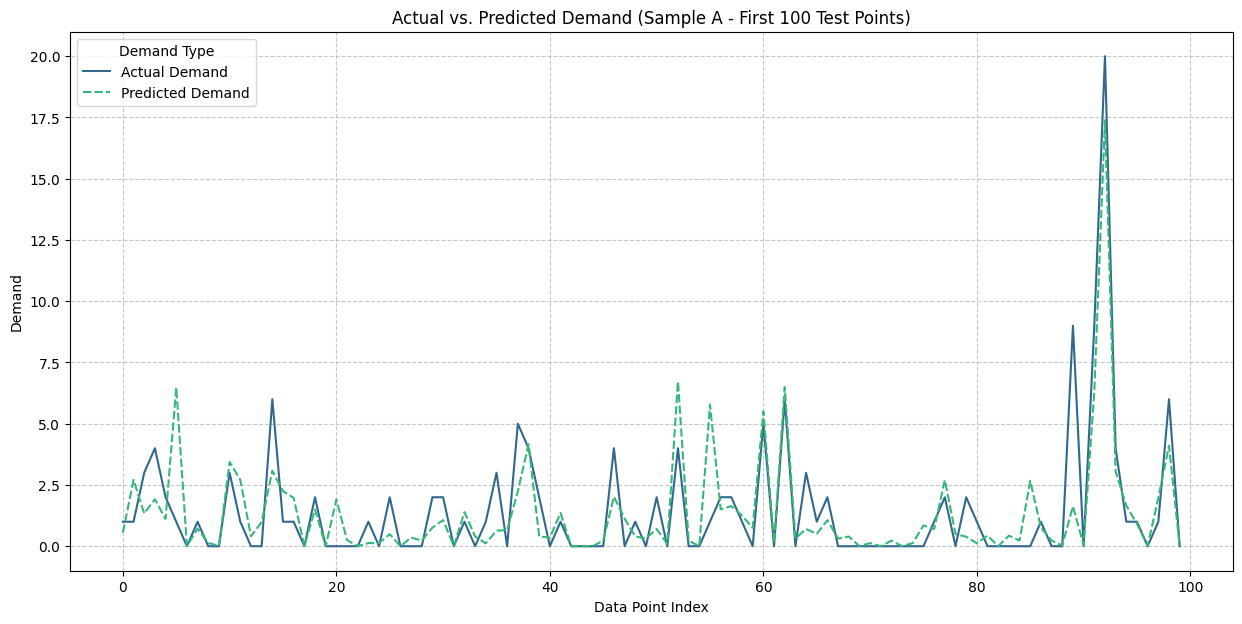

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-obtain feature columns for Sample A
feature_cols_A = prepare_features(df_A, target_col=TARGET_COL)

# Re-obtain the test set for Sample A
_, _, _, _, _, _, _, X_test_A_raw, y_test_A = time_based_split(
    df=df_A,
    target_col=TARGET_COL,
    feature_cols=feature_cols_A
)

# Get cat_features from the previously run pipeline for Sample A
cat_features_A = results_A['cat_features']

# Process X_test_A_raw using these cat_features
X_test_A_processed = X_test_A_raw.copy()
for col in cat_features_A:
    if col in X_test_A_processed.columns: # Ensure column exists in test set
        X_test_A_processed[col] = X_test_A_processed[col].astype(str).fillna('missing')

# Make predictions using the final model for Sample A
final_model_A = results_A['final_model']
predictions_A = final_model_A.predict(X_test_A_processed)

# Clip predictions to be non-negative
predictions_A = np.clip(predictions_A, 0, None)

# Create a DataFrame for actual vs. predicted values
plot_df_A = pd.DataFrame({
    'Actual Demand': y_test_A.values,
    'Predicted Demand': predictions_A
})

# Visualize a sample of the predictions (e.g., first 100 points)
plt.figure(figsize=(15, 7))
sns.lineplot(data=plot_df_A.head(100), palette='viridis')
plt.title('Actual vs. Predicted Demand (Sample A - First 100 Test Points)')
plt.xlabel('Data Point Index')
plt.ylabel('Demand')
plt.legend(title='Demand Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The plot above shows the actual versus predicted demand for the first 100 data points in the test set of 'Sample A'. This gives a visual indication of how well the model is capturing the demand patterns. A closer alignment between the 'Actual Demand' and 'Predicted Demand' lines indicates better model performance.

###Visualize Predicted vs. Actual Demand for Sample B

Excluded columns: ['date', 'id', 'd', 'demand']
Number of selected features: 45
Selected features:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'month_year', 'CAUR', 'CPIAUCSL', 'CPIUFDSL', 'FEDFUNDS_diff2', 'TXUR', 'UNRATE', 'UMCSENT_diff', 'WIUR', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28', 'demand_rolling_mean_7', 'demand_rolling_std_7', 'demand_rolling_mean_14', 'demand_rolling_std_14', 'demand_rolling_mean_28', 'demand_rolling_std_28', 'price_lag_1', 'price_lag_7', 'price_rolling_mean_7', 'price_rolling_std_7', 'price_rolling_mean_28', 'price_rolling_std_28', 'sell_price_normalized', 'price_change_flag', 'price_change_direction']
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


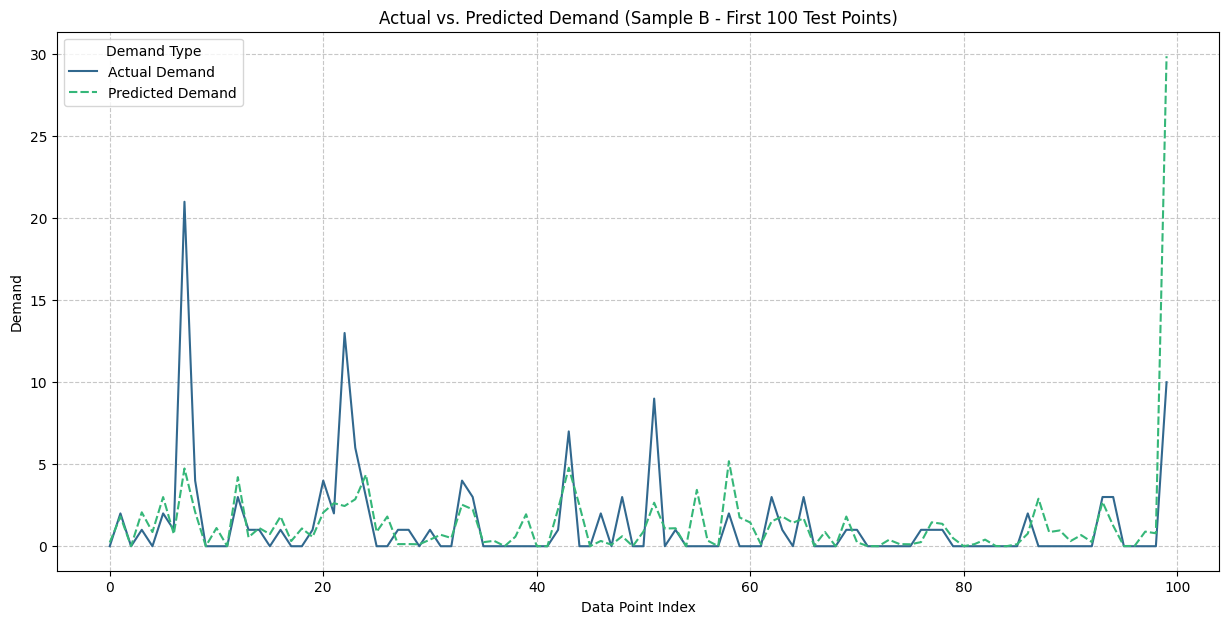

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-obtain feature columns for Sample B
feature_cols_B = prepare_features(df_B, target_col=TARGET_COL)

# Re-obtain the test set for Sample B
_, _, _, _, _, _, _, X_test_B_raw, y_test_B = time_based_split(
    df=df_B,
    target_col=TARGET_COL,
    feature_cols=feature_cols_B
)

# Get cat_features from the previously run pipeline for Sample B
cat_features_B = results_B['cat_features']

# Process X_test_B_raw using these cat_features
X_test_B_processed = X_test_B_raw.copy()
for col in cat_features_B:
    if col in X_test_B_processed.columns:
        X_test_B_processed[col] = X_test_B_processed[col].astype(str).fillna('missing')

# Make predictions using the final model for Sample B
final_model_B = results_B['final_model']
predictions_B = final_model_B.predict(X_test_B_processed)

# Clip predictions to be non-negative
predictions_B = np.clip(predictions_B, 0, None)

# Create a DataFrame for actual vs. predicted values
plot_df_B = pd.DataFrame({
    'Actual Demand': y_test_B.values,
    'Predicted Demand': predictions_B
})

# Visualize a sample of the predictions (e.g., first 100 points)
plt.figure(figsize=(15, 7))
sns.lineplot(data=plot_df_B.head(100), palette='viridis')
plt.title('Actual vs. Predicted Demand (Sample B - First 100 Test Points)')
plt.xlabel('Data Point Index')
plt.ylabel('Demand')
plt.legend(title='Demand Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This plot displays the actual versus predicted demand for the first 100 data points in the test set of 'Sample B'. It allows for a visual assessment of how closely the model's predictions align with the true demand values for this sample.

###Visualize Predicted vs. Actual Demand for Sample C

Excluded columns: ['date', 'id', 'd', 'demand']
Number of selected features: 45
Selected features:
['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'wm_yr_wk', 'weekday', 'wday', 'month', 'year', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI', 'sell_price', 'month_year', 'CAUR', 'CPIAUCSL', 'CPIUFDSL', 'FEDFUNDS_diff2', 'TXUR', 'UNRATE', 'UMCSENT_diff', 'WIUR', 'demand_lag_7', 'demand_lag_14', 'demand_lag_28', 'demand_rolling_mean_7', 'demand_rolling_std_7', 'demand_rolling_mean_14', 'demand_rolling_std_14', 'demand_rolling_mean_28', 'demand_rolling_std_28', 'price_lag_1', 'price_lag_7', 'price_rolling_mean_7', 'price_rolling_std_7', 'price_rolling_mean_28', 'price_rolling_std_28', 'sell_price_normalized', 'price_change_flag', 'price_change_direction']
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


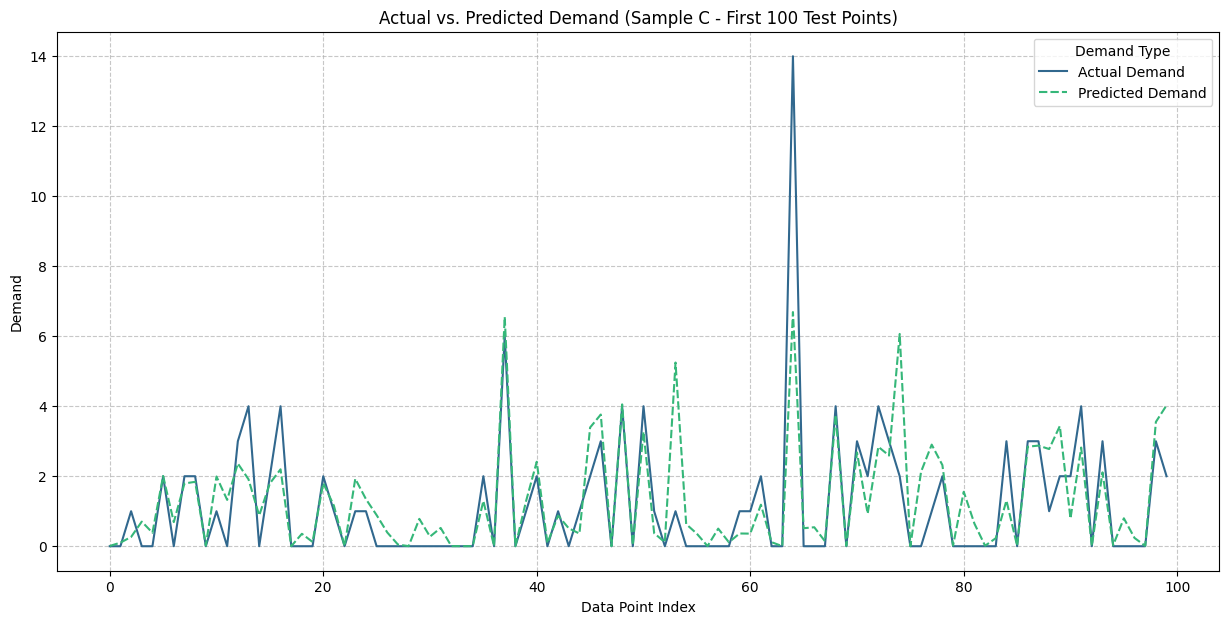

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Re-obtain feature columns for Sample C
feature_cols_C = prepare_features(df_C, target_col=TARGET_COL)

# Re-obtain the test set for Sample C
_, _, _, _, _, _, _, X_test_C_raw, y_test_C = time_based_split(
    df=df_C,
    target_col=TARGET_COL,
    feature_cols=feature_cols_C
)

# Get cat_features from the previously run pipeline for Sample C
cat_features_C = results_C['cat_features']

# Process X_test_C_raw using these cat_features
X_test_C_processed = X_test_C_raw.copy()
for col in cat_features_C:
    if col in X_test_C_processed.columns:
        X_test_C_processed[col] = X_test_C_processed[col].astype(str).fillna('missing')

# Make predictions using the final model for Sample C
final_model_C = results_C['final_model']
predictions_C = final_model_C.predict(X_test_C_processed)

# Clip predictions to be non-negative
predictions_C = np.clip(predictions_C, 0, None)

# Create a DataFrame for actual vs. predicted values
plot_df_C = pd.DataFrame({
    'Actual Demand': y_test_C.values,
    'Predicted Demand': predictions_C
})

# Visualize a sample of the predictions (e.g., first 100 points)
plt.figure(figsize=(15, 7))
sns.lineplot(data=plot_df_C.head(100), palette='viridis')
plt.title('Actual vs. Predicted Demand (Sample C - First 100 Test Points)')
plt.xlabel('Data Point Index')
plt.ylabel('Demand')
plt.legend(title='Demand Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

This final plot illustrates the actual versus predicted demand for the first 100 data points in the test set of 'Sample C'. It provides another visual check on how well the model generalizes and captures the demand patterns for this particular sample.

###20. Visualize Predicted vs. Actual Demand for All Test Samples (Combined)

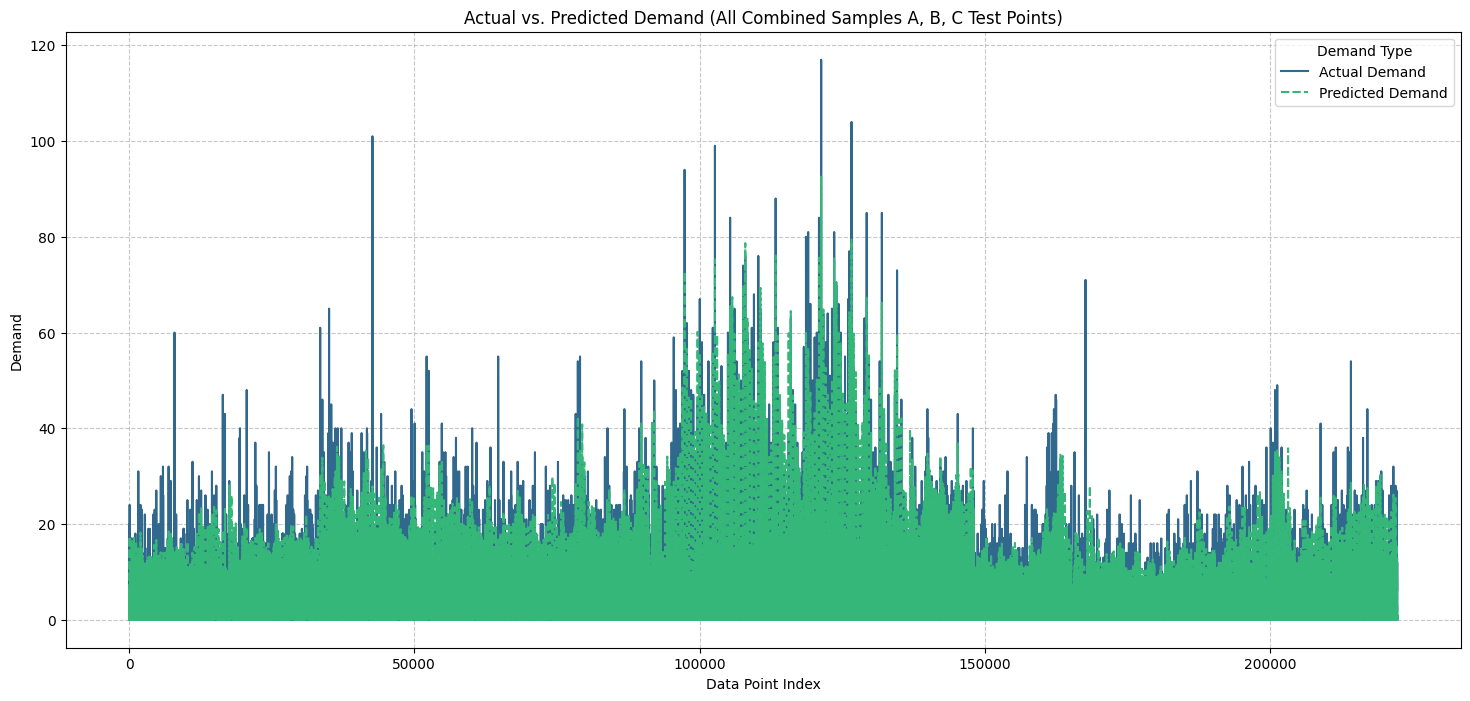

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the plot dataframes for all samples
combined_plot_df = pd.concat([plot_df_A, plot_df_B, plot_df_C]).reset_index(drop=True)

# Visualize all combined predictions
plt.figure(figsize=(18, 8))
sns.lineplot(data=combined_plot_df, palette='viridis')
plt.title('Actual vs. Predicted Demand (All Combined Samples A, B, C Test Points)')
plt.xlabel('Data Point Index')
plt.ylabel('Demand')
plt.legend(title='Demand Type')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Forecasting Explanation

### **SAHP Global Explanation**

In [ ]:
# =====================================================
# SHAP Analysis for CatBoost
# =====================================================

import shap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def explain_catboost_with_shap(
    model,
    X_test,
    feature_cols,
    sample_name,
    explain_size=1000
):
    """
    SHAP explainability for CatBoost using 2D tabular data.
    """

    print("===============================")
    print(f"SHAP Analysis for {sample_name}")
    print("===============================")

    # Ensure X_test is limited to explain_size for performance
    X_test_sampled = X_test.iloc[:explain_size].copy()

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_sampled)

    # Global feature importance
    feature_importance = np.mean(np.abs(shap_values), axis=0)

    shap_feature_df = pd.DataFrame({
        "Feature": feature_cols,
        "Mean_ABS_SHAP": feature_importance
    }).sort_values("Mean_ABS_SHAP", ascending=False)

    print("Top 15 Global SHAP Features:")
    display(shap_feature_df.head(15))

    plt.figure(figsize=(10, 7))
    plt.barh(
        shap_feature_df.head(15)["Feature"],
        shap_feature_df.head(15)["Mean_ABS_SHAP"]
    )
    plt.gca().invert_yaxis()
    plt.title(f"{sample_name} - Top 15 SHAP Feature Importance")
    plt.xlabel("Mean Absolute SHAP Value")
    plt.ylabel("Feature")
    plt.show()

    # SHAP summary plot
    shap.summary_plot(
        shap_values,
        X_test_sampled,
        feature_names=feature_cols,
        show=True
    )

    # Price-related features
    price_features = [
        col for col in feature_cols
        if "price" in col.lower() or "sell_price" in col.lower()
    ]

    price_shap_df = shap_feature_df[
        shap_feature_df["Feature"].isin(price_features)
    ]

    print("Price-Related SHAP Importance:")
    display(price_shap_df)

    # External variables
    external_features = [
        "CPIAUCSL", "CPIUFDSL", "FEDFUNDS", "FEDFUNDS_diff2",
        "UNRATE", "UMCSENT", "UMCSENT_diff",
        "CAUR", "TXUR", "WIUR"
    ]

    external_features = [
        col for col in external_features
        if col in feature_cols
    ]

    external_shap_df = shap_feature_df[
        shap_feature_df["Feature"].isin(external_features)
    ]

    print("External Variable SHAP Importance:")
    display(external_shap_df)

    return shap_values, shap_feature_df, price_shap_df, external_shap_df

SHAP Analysis for Sample_A
Top 15 Global SHAP Features:


,Feature,Mean_ABS_SHAP
30,demand_rolling_mean_7,0.862593
31,demand_rolling_std_7,0.122964
32,demand_rolling_mean_14,0.063285
7,wday,0.053906
6,weekday,0.041893
2,cat_id,0.024689
10,event_name_1,0.021789
14,snap_CA,0.019284
34,demand_rolling_mean_28,0.018481
18,month_year,0.011372


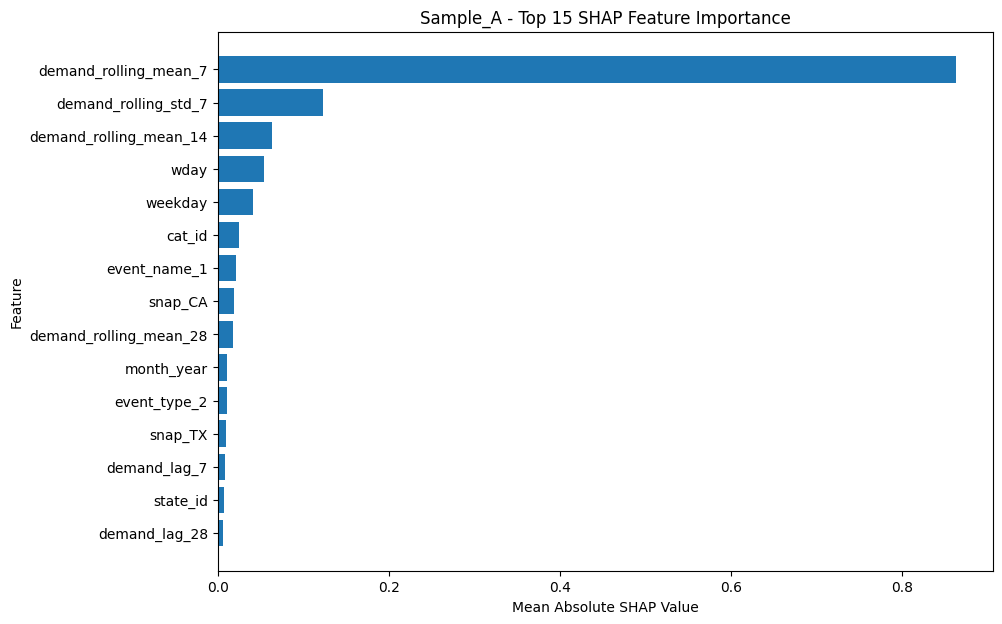

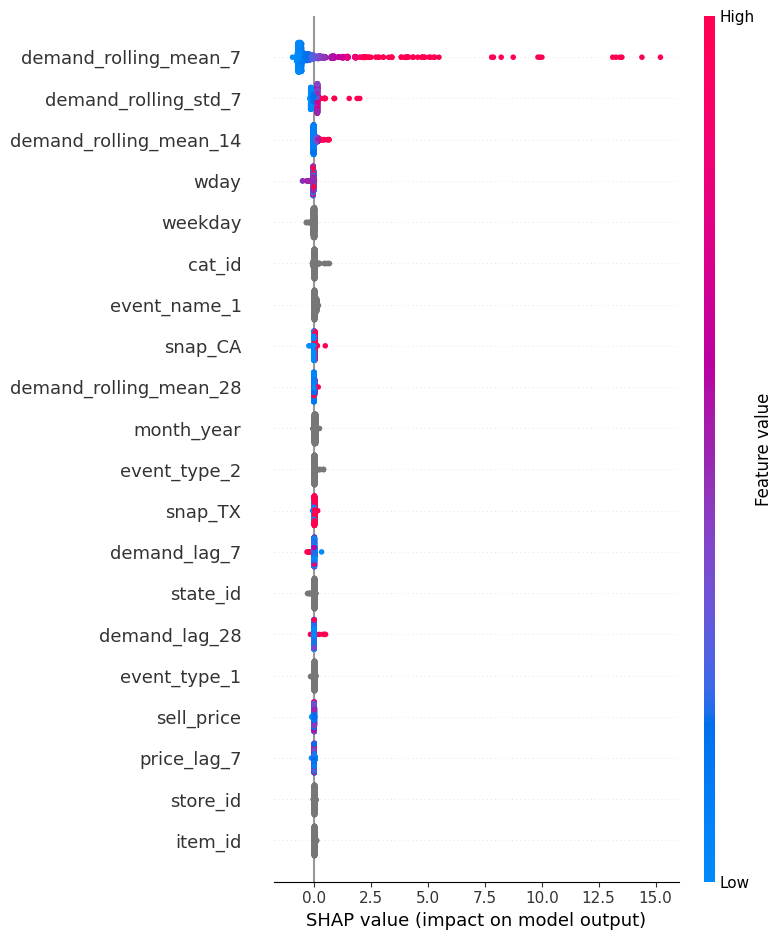

Price-Related SHAP Importance:


,Feature,Mean_ABS_SHAP
17,sell_price,0.005819
37,price_lag_7,0.004009
39,price_rolling_std_7,0.002511
38,price_rolling_mean_7,0.000798
41,price_rolling_std_28,0.000574
42,sell_price_normalized,0.000378
36,price_lag_1,0.000352
40,price_rolling_mean_28,0.000294
43,price_change_flag,0.000262
44,price_change_direction,0.000037


External Variable SHAP Importance:


,Feature,Mean_ABS_SHAP
26,WIUR,0.001632
24,UNRATE,0.001423
21,CPIUFDSL,0.000819
22,FEDFUNDS_diff2,0.000465
23,TXUR,0.000446
25,UMCSENT_diff,0.000347
20,CPIAUCSL,0.000209
19,CAUR,0.000076


In [ ]:
shap_values_A, shap_features_A, price_shap_A, external_shap_A = explain_catboost_with_shap(
    model=results_A['final_model'],
    X_test=X_test_A_processed,
    feature_cols=feature_cols_A,
    sample_name="Sample_A"
)

SHAP Analysis for Sample_B
Top 15 Global SHAP Features:


,Feature,Mean_ABS_SHAP
30,demand_rolling_mean_7,0.975307
31,demand_rolling_std_7,0.177546
32,demand_rolling_mean_14,0.126191
7,wday,0.098359
34,demand_rolling_mean_28,0.047601
6,weekday,0.026675
14,snap_CA,0.020136
29,demand_lag_28,0.019002
27,demand_lag_7,0.017380
33,demand_rolling_std_14,0.015639


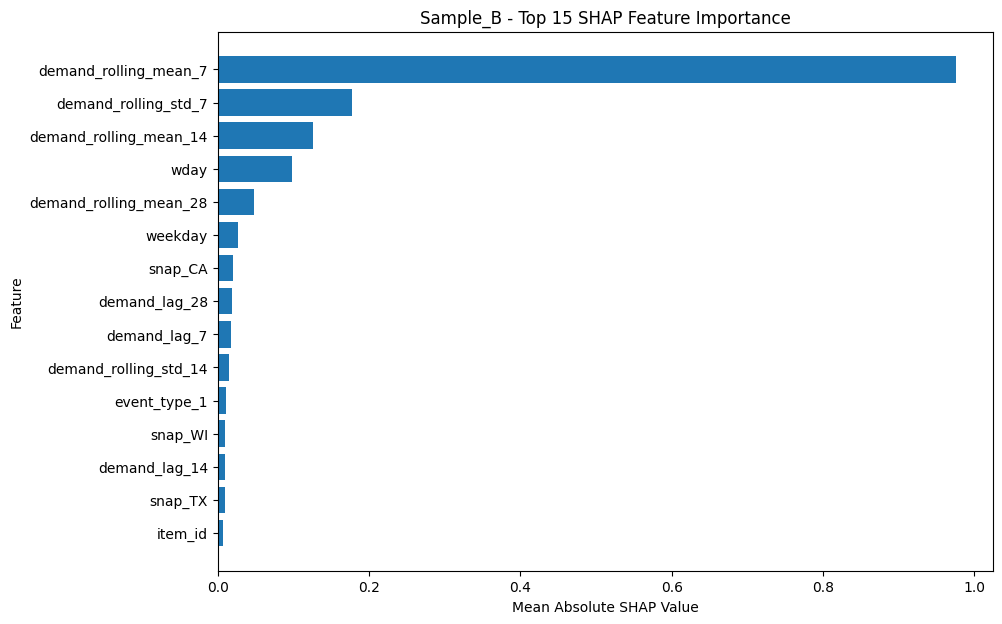

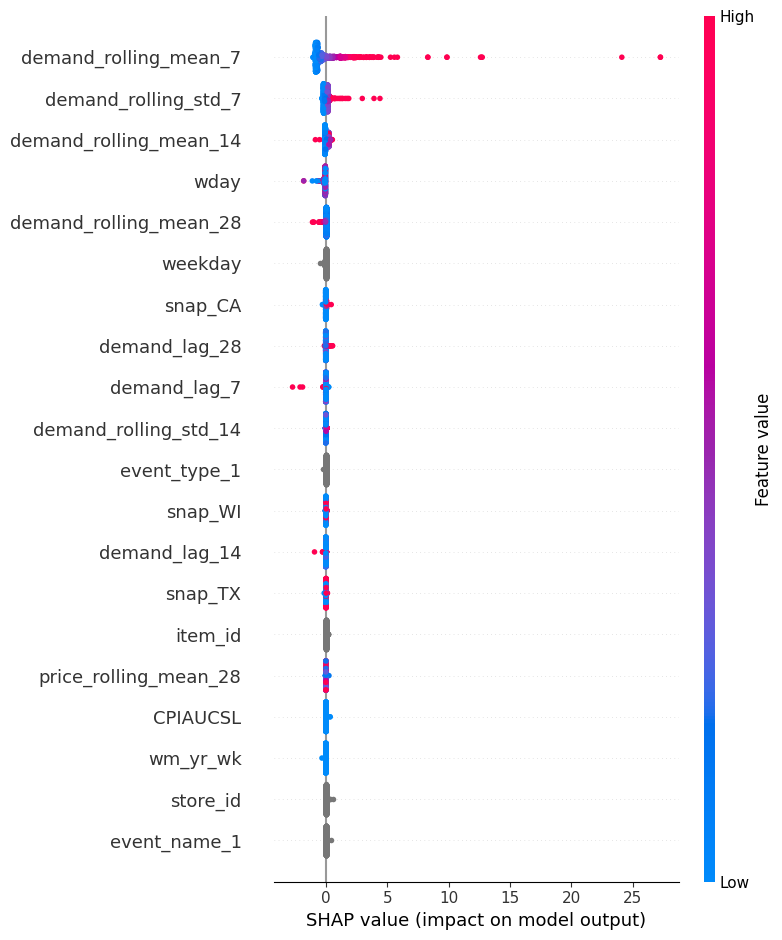

Price-Related SHAP Importance:


,Feature,Mean_ABS_SHAP
40,price_rolling_mean_28,0.006865
39,price_rolling_std_7,0.003124
41,price_rolling_std_28,0.002419
42,sell_price_normalized,0.001044
36,price_lag_1,0.000914
38,price_rolling_mean_7,0.000763
37,price_lag_7,0.000619
17,sell_price,0.000437
43,price_change_flag,0.000064
44,price_change_direction,0.000000


External Variable SHAP Importance:


,Feature,Mean_ABS_SHAP
20,CPIAUCSL,0.006080
22,FEDFUNDS_diff2,0.001463
25,UMCSENT_diff,0.000887
19,CAUR,0.000877
21,CPIUFDSL,0.000472
23,TXUR,0.000187
26,WIUR,0.000138
24,UNRATE,0.000034


In [ ]:
shap_values_B, shap_features_B, price_shap_B, external_shap_B = explain_catboost_with_shap(
    model=results_B['final_model'],
    X_test=X_test_B_processed,
    feature_cols=feature_cols_B,
    sample_name="Sample_B"
)

SHAP Analysis for Sample_C
Top 15 Global SHAP Features:


,Feature,Mean_ABS_SHAP
30,demand_rolling_mean_7,0.844292
31,demand_rolling_std_7,0.161159
32,demand_rolling_mean_14,0.065224
6,weekday,0.063278
7,wday,0.050229
27,demand_lag_7,0.023149
34,demand_rolling_mean_28,0.020554
28,demand_lag_14,0.019914
15,snap_TX,0.012166
29,demand_lag_28,0.011757


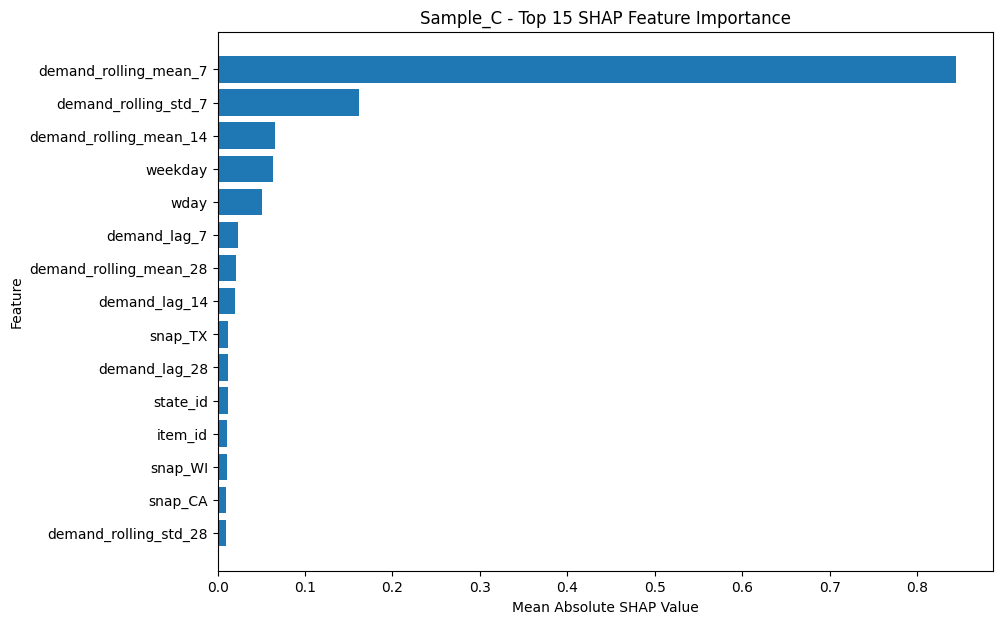

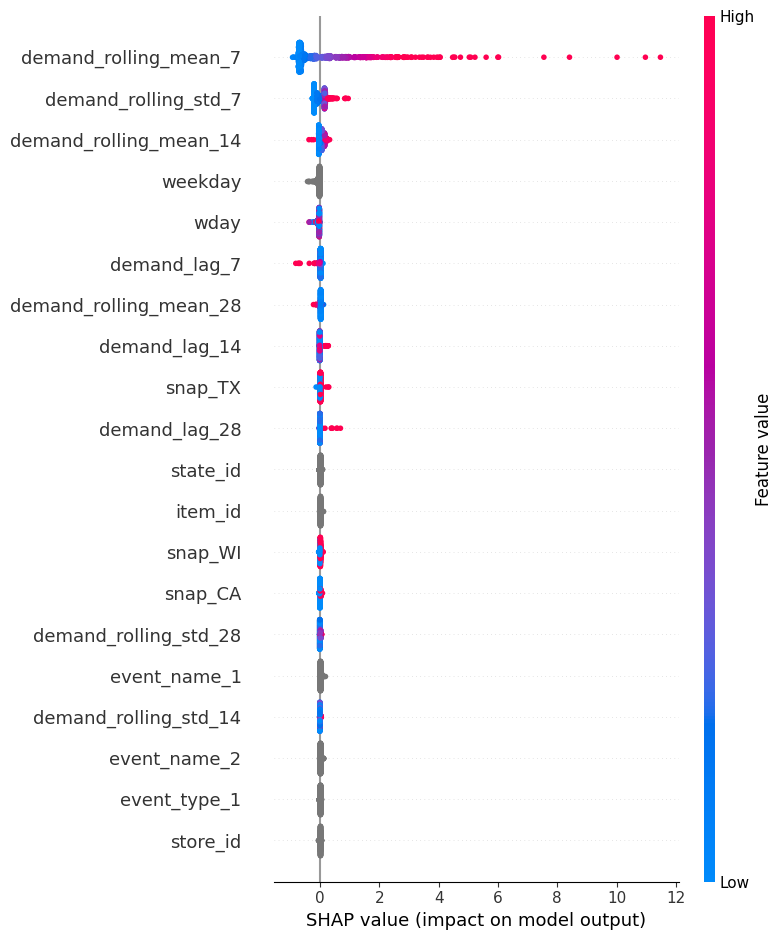

Price-Related SHAP Importance:


,Feature,Mean_ABS_SHAP
39,price_rolling_std_7,0.002821
42,sell_price_normalized,0.000980
40,price_rolling_mean_28,0.000854
36,price_lag_1,0.000681
37,price_lag_7,0.000258
38,price_rolling_mean_7,0.000184
17,sell_price,0.000166
43,price_change_flag,0.000025
44,price_change_direction,0.000010
41,price_rolling_std_28,0.000000


External Variable SHAP Importance:


,Feature,Mean_ABS_SHAP
22,FEDFUNDS_diff2,0.002185
24,UNRATE,0.001017
23,TXUR,0.000790
20,CPIAUCSL,0.000777
19,CAUR,0.000518
25,UMCSENT_diff,0.000395
26,WIUR,0.000296
21,CPIUFDSL,0.000182


In [ ]:
shap_values_C, shap_features_C, price_shap_C, external_shap_C = explain_catboost_with_shap(
    model=results_C['final_model'],
    X_test=X_test_C_processed,
    feature_cols=feature_cols_C,
    sample_name="Sample_C"
)

### PDP Explanation Function

In [ ]:
# =====================================================
# PDP-Style Sensitivity Analysis for CatBoost
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def catboost_sensitivity_plot(
    results,
    df,
    feature_name,
    sample_name,
    target_col='demand',
    n_samples=300,
    grid_points=20,
    range_source="auto"
):
    """
    PDP-style sensitivity analysis for CatBoost.

    range_source:
    - "local": use selected X_test subset range
    - "global": use full dataframe range
    - "auto": use global range for macro variables, local range for other features
    """

    print("===============================")
    print(f"PDP Analysis for {sample_name}")
    print("===============================")

    feature_cols = results["feature_cols"]
    cat_features = results["cat_features"]
    model = results["final_model"]

    _, _, _, _, _, _, _, X_test, y_test = time_based_split(
        df=df,
        target_col=target_col,
        feature_cols=feature_cols
    )

    X_base = X_test.iloc[:n_samples].copy()

    for col in cat_features:
        if col in X_base.columns:
            X_base[col] = X_base[col].astype(str).fillna("missing")

    if feature_name not in feature_cols:
        raise ValueError(f"{feature_name} not found in feature_cols")

    macro_features = [
        "CPIAUCSL", "CPIUFDSL", "FEDFUNDS", "FEDFUNDS_diff",
        "FEDFUNDS_diff2", "UNRATE", "UMCSENT", "UMCSENT_diff",
        "CAUR", "TXUR", "WIUR"
    ]

    if range_source == "auto":
        if feature_name in macro_features:
            range_source_used = "global"
        else:
            range_source_used = "local"
    else:
        range_source_used = range_source

    if range_source_used == "global":
        feature_min = df[feature_name].min()
        feature_max = df[feature_name].max()
    elif range_source_used == "local":
        feature_min = X_base[feature_name].min()
        feature_max = X_base[feature_name].max()
    else:
        raise ValueError("range_source must be 'auto', 'local', or 'global'")

    print(f"Feature: {feature_name}")
    print(f"Range source used: {range_source_used}")
    print(f"Range: {feature_min} -> {feature_max}")

    if feature_min == feature_max:
        print("Warning: feature_min equals feature_max. PDP will show one constant value.")

    grid_values = np.linspace(
        feature_min,
        feature_max,
        grid_points
    )

    avg_predictions = []

    for value in grid_values:

        X_temp = X_base.copy()
        X_temp[feature_name] = value

        pred = model.predict(X_temp)
        pred = np.maximum(pred, 0)

        avg_predictions.append(pred.mean())

    sensitivity_df = pd.DataFrame({
        feature_name: grid_values,
        "Average_Predicted_Demand": avg_predictions
    })

    plt.figure(figsize=(9, 5))

    plt.plot(
        sensitivity_df[feature_name],
        sensitivity_df["Average_Predicted_Demand"],
        marker='o'
    )

    plt.title(f"{sample_name} - PDP-Style Sensitivity: {feature_name}")
    plt.xlabel(feature_name)
    plt.ylabel("Average Predicted Demand")
    plt.grid(True)
    plt.show()

    display(sensitivity_df)

    return sensitivity_df

### Price Sensitivity (PDP)

PDP Analysis for Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: sell_price
Range source used: local
Range: 0.2 -> 22.98


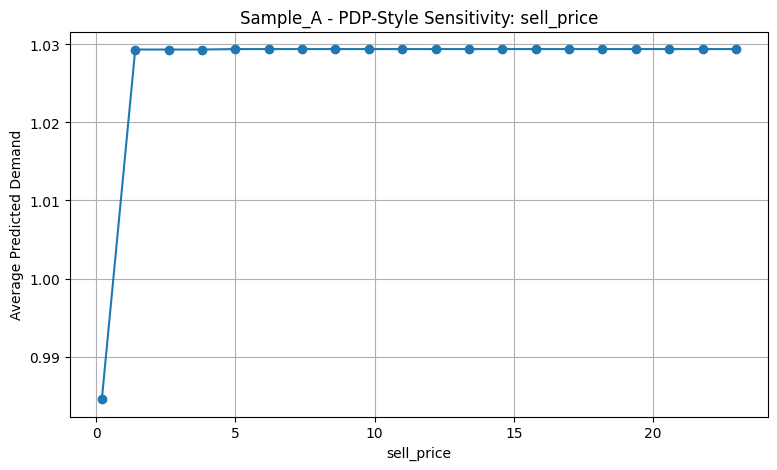

,sell_price,Average_Predicted_Demand
0,0.200000,0.984553
1,1.398947,1.029338
2,2.597895,1.029338
3,3.796842,1.029338
4,4.995789,1.029395
5,6.194737,1.029395
6,7.393684,1.029395
7,8.592632,1.029395
8,9.791579,1.029395
9,10.990526,1.029395


In [ ]:
price_sensitivity_A = catboost_sensitivity_plot(
    results=results_A,
    df=df_A,
    feature_name="sell_price",
    sample_name="Sample_A",
    target_col=TARGET_COL,
    n_samples=300,
    grid_points=20,
    range_source="local"
)


PDP Analysis for Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: sell_price
Range source used: local
Range: 0.2 -> 26.98


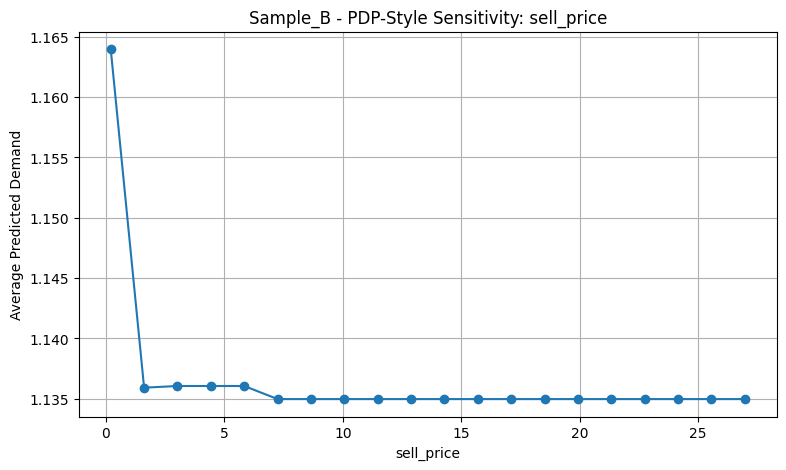

,sell_price,Average_Predicted_Demand
0,0.200000,1.163977
1,1.609474,1.135904
2,3.018947,1.136043
3,4.428421,1.136043
4,5.837895,1.136043
5,7.247368,1.134959
6,8.656842,1.134959
7,10.066316,1.134959
8,11.475789,1.134959
9,12.885263,1.134959


In [ ]:
price_sensitivity_B = catboost_sensitivity_plot(
    results=results_B,
    df=df_B,
    feature_name="sell_price",
    sample_name="Sample_B",
    target_col=TARGET_COL,
    n_samples=300,
    grid_points=20,
    range_source="local"
)

PDP Analysis for Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: sell_price
Range source used: local
Range: 0.23 -> 18.73


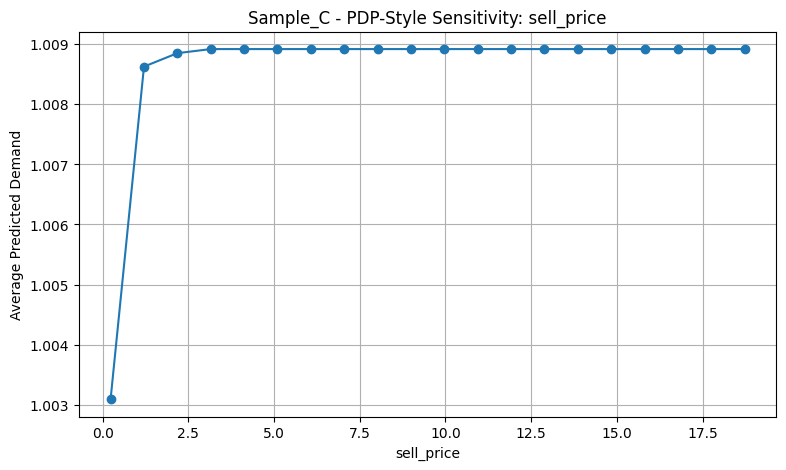

,sell_price,Average_Predicted_Demand
0,0.230000,1.003097
1,1.203684,1.008624
2,2.177368,1.008848
3,3.151053,1.008916
4,4.124737,1.008916
5,5.098421,1.008916
6,6.072105,1.008916
7,7.045789,1.008916
8,8.019474,1.008916
9,8.993158,1.008916


In [ ]:
price_sensitivity_C = catboost_sensitivity_plot(
    results=results_C,
    df=df_C,
    feature_name="sell_price",
    sample_name="Sample_C",
    target_col=TARGET_COL,
    n_samples=300,
    grid_points=20,
    range_source="local"
)

### Extranal Macroeconomic Sensetivity (PDP)

PDP Analysis for Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: CPIAUCSL
Range source used: global
Range: 221.187 -> 239.557


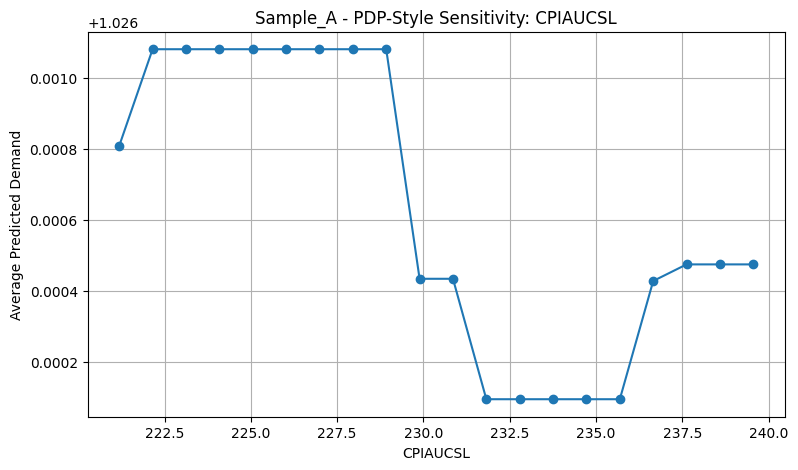

,CPIAUCSL,Average_Predicted_Demand
0,221.187000,1.026808
1,222.153842,1.027080
2,223.120684,1.027080
3,224.087526,1.027080
4,225.054368,1.027080
5,226.021211,1.027080
6,226.988053,1.027080
7,227.954895,1.027080
8,228.921737,1.027080
9,229.888579,1.026434


PDP Analysis for Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: CAUR
Range source used: global
Range: 5.5 -> 12.1


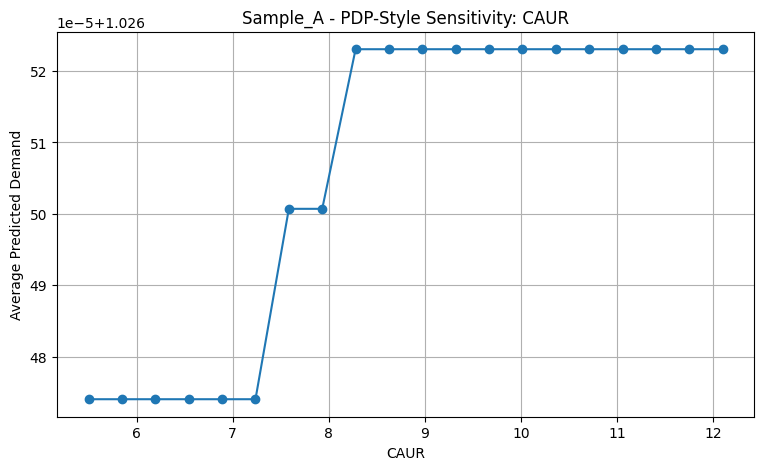

,CAUR,Average_Predicted_Demand
0,5.500000,1.026474
1,5.847368,1.026474
2,6.194737,1.026474
3,6.542105,1.026474
4,6.889474,1.026474
5,7.236842,1.026474
6,7.584211,1.026501
7,7.931579,1.026501
8,8.278947,1.026523
9,8.626316,1.026523


PDP Analysis for Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: TXUR
Range source used: global
Range: 4.4 -> 8.4


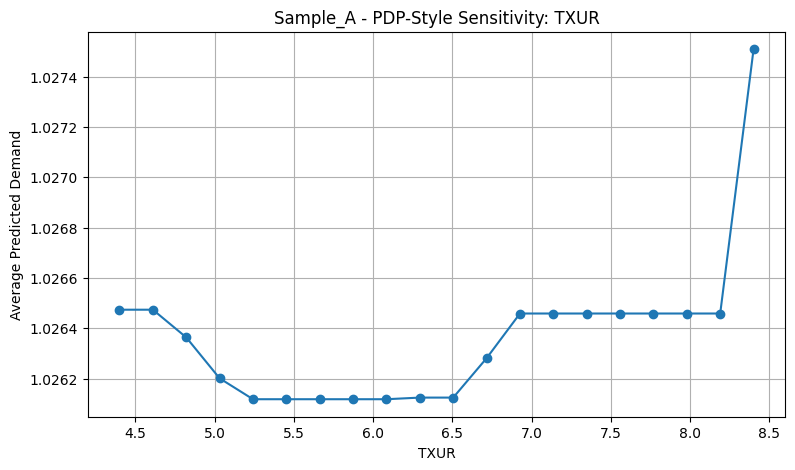

,TXUR,Average_Predicted_Demand
0,4.400000,1.026474
1,4.610526,1.026474
2,4.821053,1.026364
3,5.031579,1.026202
4,5.242105,1.026119
5,5.452632,1.026119
6,5.663158,1.026119
7,5.873684,1.026119
8,6.084211,1.026119
9,6.294737,1.026125


PDP Analysis for Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: WIUR
Range source used: global
Range: 4.0 -> 7.8


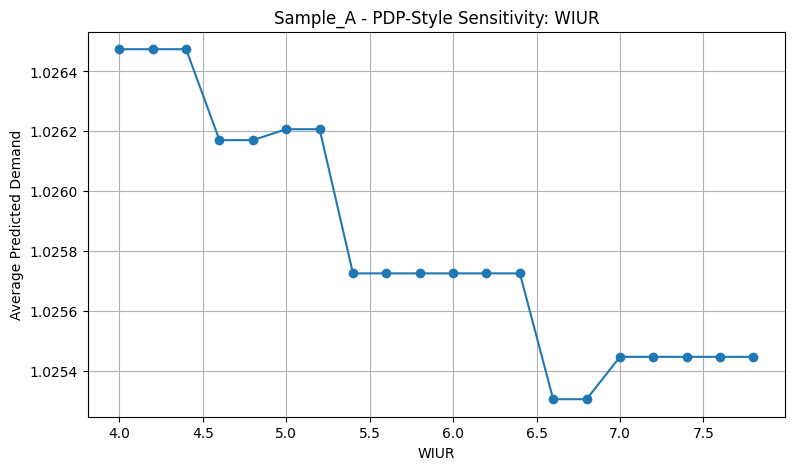

,WIUR,Average_Predicted_Demand
0,4.0,1.026474
1,4.2,1.026474
2,4.4,1.026474
3,4.6,1.026171
4,4.8,1.026171
5,5.0,1.026207
6,5.2,1.026207
7,5.4,1.025726
8,5.6,1.025726
9,5.8,1.025726


PDP Analysis for Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: FEDFUNDS_diff2
Range source used: global
Range: -0.06 -> 0.12


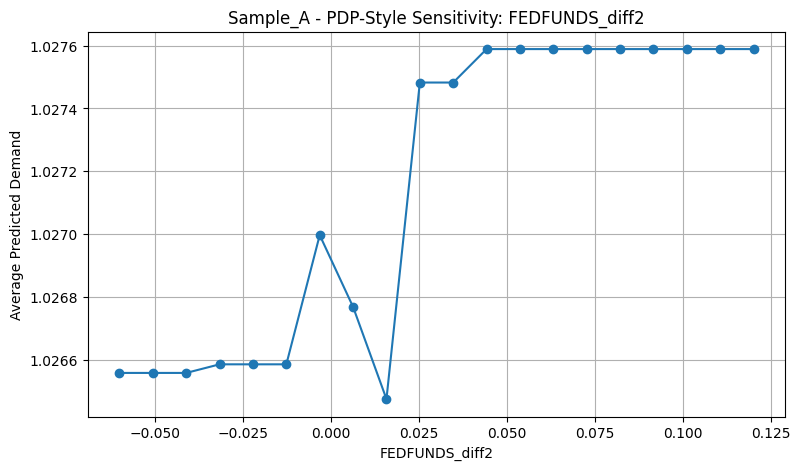

,FEDFUNDS_diff2,Average_Predicted_Demand
0,-0.060000,1.026557
1,-0.050526,1.026557
2,-0.041053,1.026557
3,-0.031579,1.026585
4,-0.022105,1.026585
5,-0.012632,1.026585
6,-0.003158,1.026996
7,0.006316,1.026768
8,0.015789,1.026474
9,0.025263,1.027482


In [ ]:
external_sensitivity_results_A = {}

for macro_feature in ["CPIAUCSL","CAUR", "TXUR", "WIUR", "FEDFUNDS_diff2"]:

    if macro_feature in results_A["feature_cols"]:

        external_sensitivity_results_A[macro_feature] = catboost_sensitivity_plot(
            results=results_A,
            df=df_A,
            feature_name=macro_feature,
            sample_name="Sample_A",
            target_col=TARGET_COL,
            n_samples=300,
            grid_points=20,
            range_source="global"
        )

PDP Analysis for Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: CPIAUCSL
Range source used: global
Range: 221.187 -> 239.557


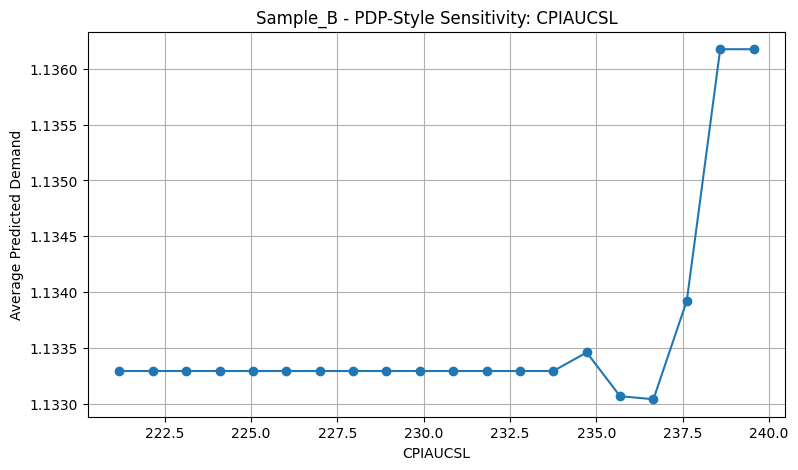

,CPIAUCSL,Average_Predicted_Demand
0,221.187000,1.133292
1,222.153842,1.133292
2,223.120684,1.133292
3,224.087526,1.133292
4,225.054368,1.133292
5,226.021211,1.133292
6,226.988053,1.133292
7,227.954895,1.133292
8,228.921737,1.133292
9,229.888579,1.133292


PDP Analysis for Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: CAUR
Range source used: global
Range: 5.5 -> 12.1


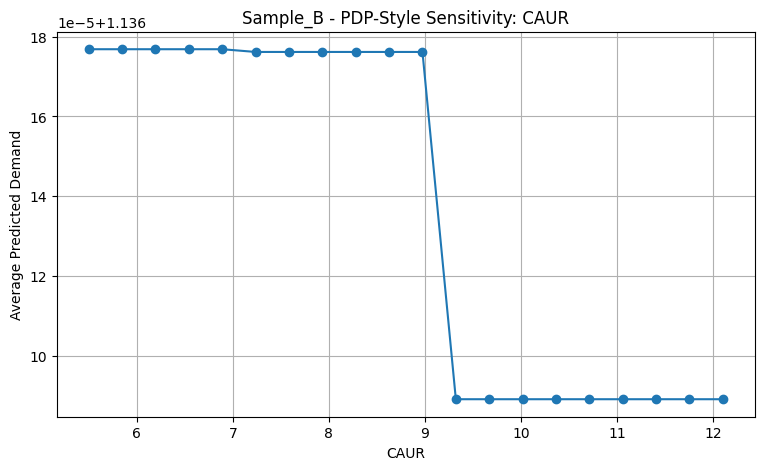

,CAUR,Average_Predicted_Demand
0,5.500000,1.136177
1,5.847368,1.136177
2,6.194737,1.136177
3,6.542105,1.136177
4,6.889474,1.136177
5,7.236842,1.136176
6,7.584211,1.136176
7,7.931579,1.136176
8,8.278947,1.136176
9,8.626316,1.136176


PDP Analysis for Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: TXUR
Range source used: global
Range: 4.4 -> 8.4


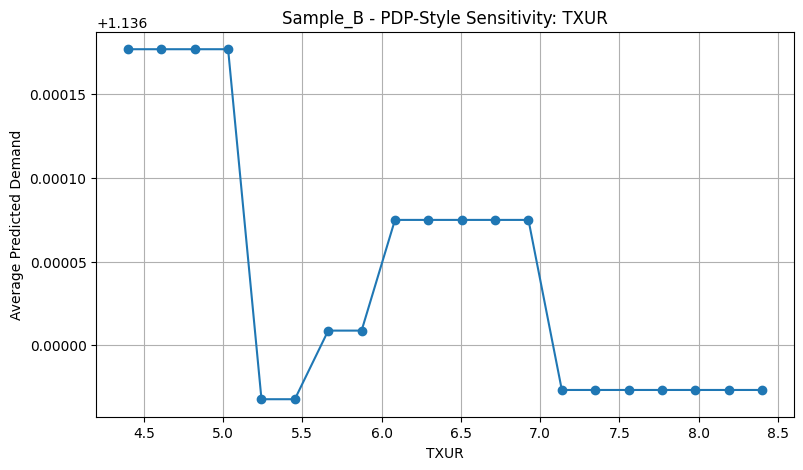

,TXUR,Average_Predicted_Demand
0,4.400000,1.136177
1,4.610526,1.136177
2,4.821053,1.136177
3,5.031579,1.136177
4,5.242105,1.135968
5,5.452632,1.135968
6,5.663158,1.136009
7,5.873684,1.136009
8,6.084211,1.136075
9,6.294737,1.136075


PDP Analysis for Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: WIUR
Range source used: global
Range: 4.0 -> 7.8


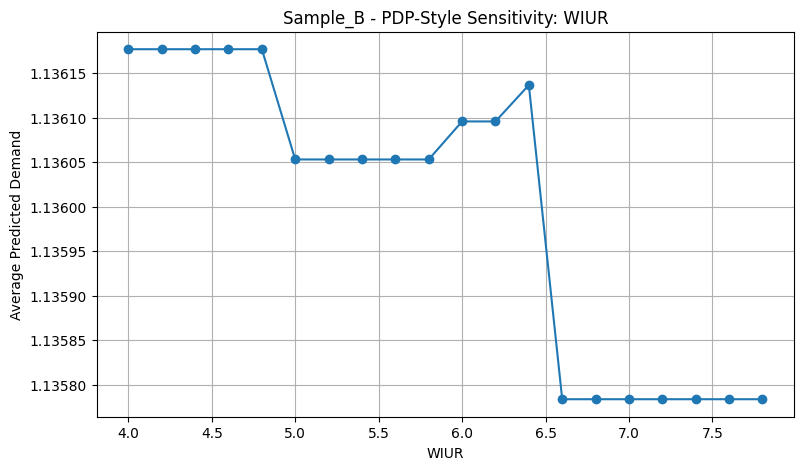

,WIUR,Average_Predicted_Demand
0,4.0,1.136177
1,4.2,1.136177
2,4.4,1.136177
3,4.6,1.136177
4,4.8,1.136177
5,5.0,1.136053
6,5.2,1.136053
7,5.4,1.136053
8,5.6,1.136053
9,5.8,1.136053


PDP Analysis for Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: FEDFUNDS_diff2
Range source used: global
Range: -0.06 -> 0.12


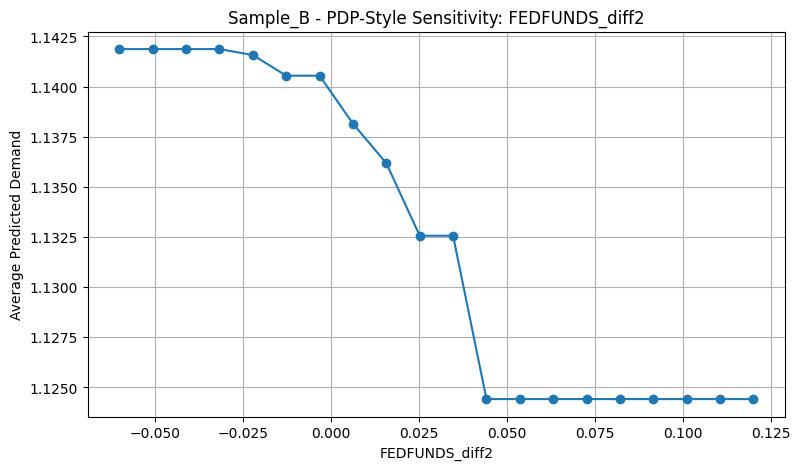

,FEDFUNDS_diff2,Average_Predicted_Demand
0,-0.060000,1.141871
1,-0.050526,1.141871
2,-0.041053,1.141871
3,-0.031579,1.141871
4,-0.022105,1.141573
5,-0.012632,1.140543
6,-0.003158,1.140543
7,0.006316,1.138152
8,0.015789,1.136177
9,0.025263,1.132561


In [ ]:
external_sensitivity_results_B = {}

for macro_feature in ["CPIAUCSL","CAUR", "TXUR", "WIUR", "FEDFUNDS_diff2"]:

    if macro_feature in results_B["feature_cols"]:

        external_sensitivity_results_A[macro_feature] = catboost_sensitivity_plot(
            results=results_B,
            df=df_B,
            feature_name=macro_feature,
            sample_name="Sample_B",
            target_col=TARGET_COL,
            n_samples=300,
            grid_points=20,
            range_source="global"
        )

PDP Analysis for Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: CPIAUCSL
Range source used: global
Range: 221.187 -> 239.557


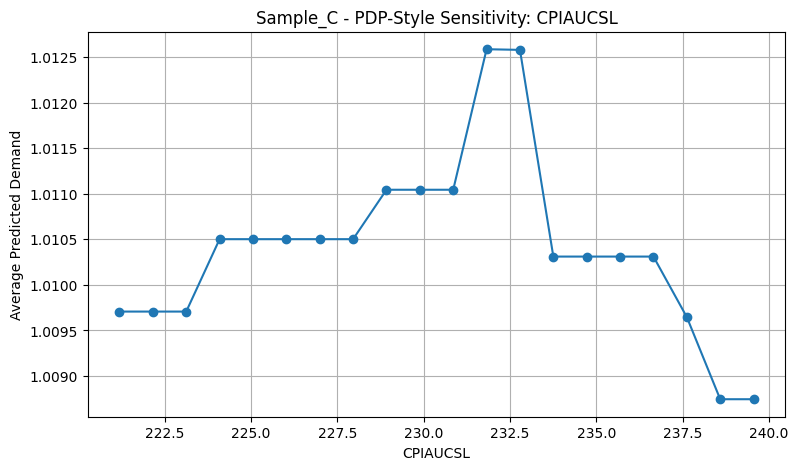

,CPIAUCSL,Average_Predicted_Demand
0,221.187000,1.009707
1,222.153842,1.009707
2,223.120684,1.009707
3,224.087526,1.010501
4,225.054368,1.010501
5,226.021211,1.010501
6,226.988053,1.010501
7,227.954895,1.010501
8,228.921737,1.011044
9,229.888579,1.011044


PDP Analysis for Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: CAUR
Range source used: global
Range: 5.5 -> 12.1


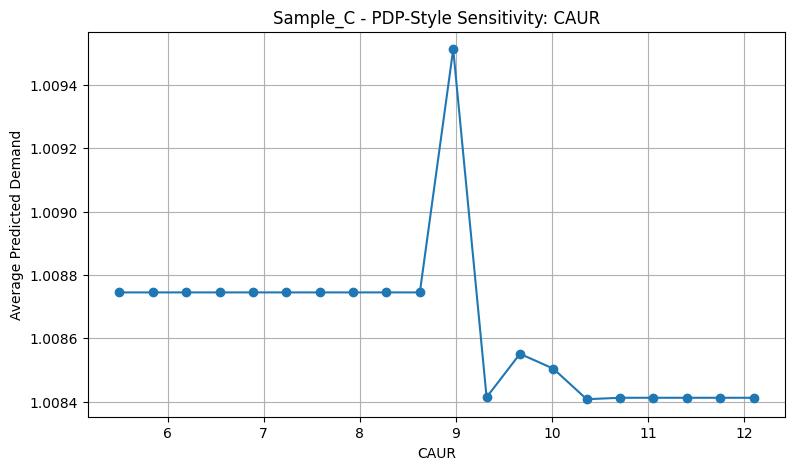

,CAUR,Average_Predicted_Demand
0,5.500000,1.008745
1,5.847368,1.008745
2,6.194737,1.008745
3,6.542105,1.008745
4,6.889474,1.008745
5,7.236842,1.008745
6,7.584211,1.008745
7,7.931579,1.008745
8,8.278947,1.008745
9,8.626316,1.008745


PDP Analysis for Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: TXUR
Range source used: global
Range: 4.4 -> 8.4


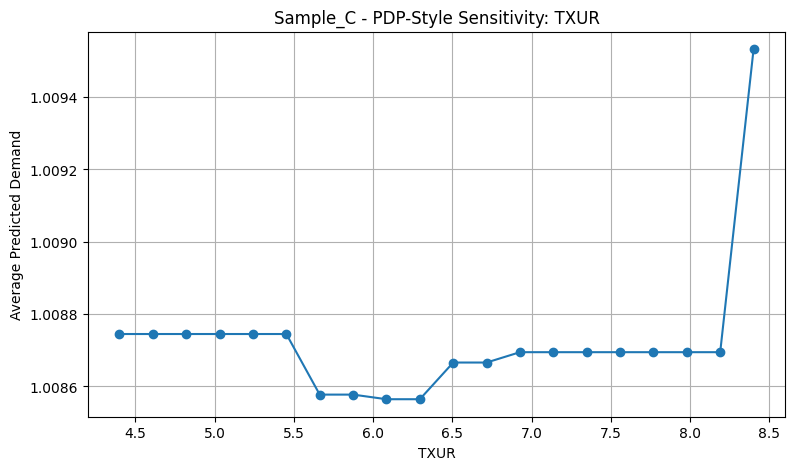

,TXUR,Average_Predicted_Demand
0,4.400000,1.008745
1,4.610526,1.008745
2,4.821053,1.008745
3,5.031579,1.008745
4,5.242105,1.008745
5,5.452632,1.008745
6,5.663158,1.008577
7,5.873684,1.008577
8,6.084211,1.008565
9,6.294737,1.008565


PDP Analysis for Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: WIUR
Range source used: global
Range: 4.0 -> 7.8


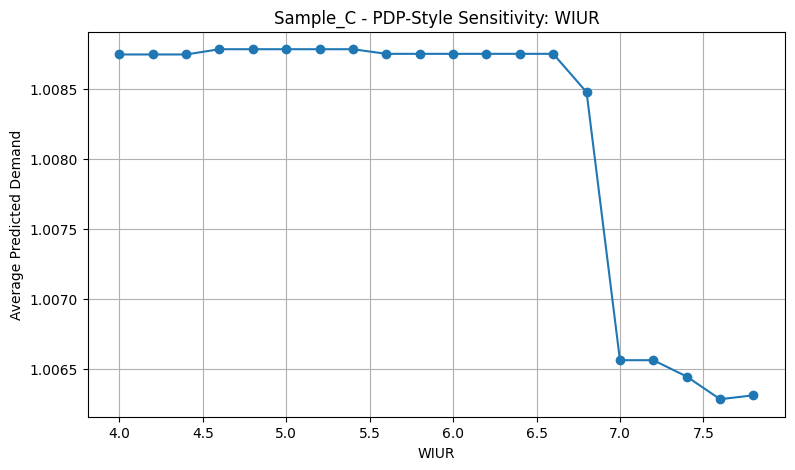

,WIUR,Average_Predicted_Demand
0,4.0,1.008745
1,4.2,1.008745
2,4.4,1.008745
3,4.6,1.008782
4,4.8,1.008782
5,5.0,1.008782
6,5.2,1.008782
7,5.4,1.008782
8,5.6,1.008750
9,5.8,1.008750


PDP Analysis for Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: FEDFUNDS_diff2
Range source used: global
Range: -0.06 -> 0.12


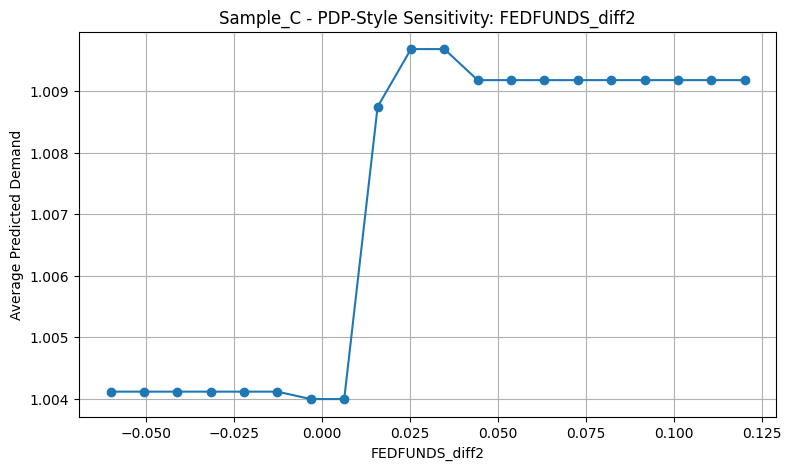

,FEDFUNDS_diff2,Average_Predicted_Demand
0,-0.060000,1.004112
1,-0.050526,1.004112
2,-0.041053,1.004112
3,-0.031579,1.004112
4,-0.022105,1.004112
5,-0.012632,1.004112
6,-0.003158,1.003991
7,0.006316,1.003991
8,0.015789,1.008745
9,0.025263,1.009685


In [ ]:
external_sensitivity_results_C = {}

for macro_feature in ["CPIAUCSL","CAUR", "TXUR", "WIUR", "FEDFUNDS_diff2"]:

    if macro_feature in results_C["feature_cols"]:

        external_sensitivity_results_C[macro_feature] = catboost_sensitivity_plot(
            results=results_C,
            df=df_C,
            feature_name=macro_feature,
            sample_name="Sample_C",
            target_col=TARGET_COL,
            n_samples=300,
            grid_points=20,
            range_source="global"
        )

## Price Optimization

### Price Optimization Function

In [ ]:
# =====================================================
# Price Optimization Analysis for CatBoost
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def price_optimization_catboost(
    results,
    df,
    sample_name,
    price_col="sell_price",
    target_col="demand",
    n_prices=20,
    row_index=0,
    price_range_source="local"
):
    """
    Price optimization for CatBoost.

    This function simulates different sell_price values,
    predicts demand, calculates expected revenue, and evaluates
    the optimized price using scenario-based evaluation metrics.

    Revenue:
        R(p) = p × D_hat(p)

    Demand Retention:
        Retention = D_hat(p*) / D_baseline
    """

    print("\n===============================")
    print(f"Price Optimization for {sample_name}")
    print("===============================")

    feature_cols = results["feature_cols"]
    cat_features = results["cat_features"]
    model = results["final_model"]

    if price_col not in feature_cols:
        raise ValueError(f"{price_col} is not in feature_cols")

    # Recreate test data
    _, _, _, _, _, _, _, X_test, y_test = time_based_split(
        df=df,
        target_col=target_col,
        feature_cols=feature_cols
    )

    X_test = X_test.copy()

    # Prepare categorical columns
    for col in cat_features:
        if col in X_test.columns:
            X_test[col] = X_test[col].astype(str).fillna("missing")

    # Select one item/scenario from test set
    base_row = X_test.iloc[row_index].copy()

    baseline_price = base_row[price_col]

    # Baseline prediction
    X_baseline = pd.DataFrame([base_row], columns=feature_cols)

    for col in cat_features:
        if col in X_baseline.columns:
            X_baseline[col] = X_baseline[col].astype(str).fillna("missing")

    baseline_predicted_demand = model.predict(X_baseline)[0]
    baseline_predicted_demand = max(baseline_predicted_demand, 0)

    baseline_revenue = baseline_price * baseline_predicted_demand

    # Display selected scenario
    print("\nSelected Optimization Scenario:")

    scenario_info = {
        "Row_Index": row_index,
        "Original_Price": baseline_price,
        "Baseline_Predicted_Demand": baseline_predicted_demand,
        "Baseline_Revenue": baseline_revenue
    }

    if target_col in df.columns:
        scenario_info["Actual_Demand"] = y_test.iloc[row_index]

    display(pd.DataFrame(scenario_info.items(), columns=["Variable", "Value"]))

    # Price range
    if price_range_source == "local":
        price_min = X_test[price_col].quantile(0.05)
        price_max = X_test[price_col].quantile(0.95)

    elif price_range_source == "global":
        price_min = df[price_col].quantile(0.05)
        price_max = df[price_col].quantile(0.95)

    else:
        raise ValueError("price_range_source must be 'local' or 'global'")

    price_range = np.linspace(price_min, price_max, n_prices)

    simulation_results = []

    for price in price_range:

        row_temp = base_row.copy()
        row_temp[price_col] = price

        X_temp = pd.DataFrame([row_temp], columns=feature_cols)

        for col in cat_features:
            if col in X_temp.columns:
                X_temp[col] = X_temp[col].astype(str).fillna("missing")

        predicted_demand = model.predict(X_temp)[0]
        predicted_demand = max(predicted_demand, 0)

        revenue = price * predicted_demand

        simulation_results.append({
            "Sample": sample_name,
            "Price": price,
            "Predicted_Demand": predicted_demand,
            "Revenue": revenue,
            "Revenue_vs_Baseline": revenue - baseline_revenue,
            "Revenue_Improvement_%": (
                ((revenue - baseline_revenue) / baseline_revenue) * 100
                if baseline_revenue != 0 else np.nan
            ),
            "Demand_Retention": (
                predicted_demand / baseline_predicted_demand
                if baseline_predicted_demand != 0 else np.nan
            )
        })

    results_df = pd.DataFrame(simulation_results)

    best_row = results_df.loc[results_df["Revenue"].idxmax()]

    # Summary evaluation
    evaluation_summary = pd.DataFrame({
        "Metric": [
            "Baseline Price",
            "Optimized Price",
            "Baseline Predicted Demand",
            "Optimized Predicted Demand",
            "Baseline Revenue",
            "Optimized Revenue",
            "Revenue Improvement",
            "Revenue Improvement (%)",
            "Demand Retention"
        ],
        "Value": [
            baseline_price,
            best_row["Price"],
            baseline_predicted_demand,
            best_row["Predicted_Demand"],
            baseline_revenue,
            best_row["Revenue"],
            best_row["Revenue_vs_Baseline"],
            best_row["Revenue_Improvement_%"],
            best_row["Demand_Retention"]
        ]
    })

    print("\nBest Price Result:")
    display(best_row)

    print("\nPrice Optimization Evaluation Summary:")
    display(evaluation_summary)

    print(
        f"\nFor {sample_name}, the optimized price is {best_row['Price']:.2f}. "
        f"This produced an expected revenue of {best_row['Revenue']:.3f}, "
        f"compared with baseline revenue of {baseline_revenue:.3f}. "
        f"The revenue improvement is {best_row['Revenue_Improvement_%']:.2f}%, "
        f"with demand retention of {best_row['Demand_Retention']:.3f}."
    )

    # Plot Price vs Demand
    plt.figure(figsize=(10, 5))
    plt.plot(results_df["Price"], results_df["Predicted_Demand"], marker="o")
    plt.axvline(baseline_price, linestyle="--", label="Baseline Price")
    plt.axvline(best_row["Price"], linestyle="--", label="Optimized Price")
    plt.title(f"{sample_name} - Price vs Predicted Demand")
    plt.xlabel("Price")
    plt.ylabel("Predicted Demand")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Plot Price vs Revenue
    plt.figure(figsize=(10, 5))
    plt.plot(results_df["Price"], results_df["Revenue"], marker="o")
    plt.axvline(baseline_price, linestyle="--", label="Baseline Price")
    plt.axvline(best_row["Price"], linestyle="--", label="Optimized Price")
    plt.title(f"{sample_name} - Price vs Expected Revenue")
    plt.xlabel("Price")
    plt.ylabel("Expected Revenue")
    plt.legend()
    plt.grid(True)
    plt.show()

    return results_df, best_row, evaluation_summary


Price Optimization for Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Selected Optimization Scenario:


,Variable,Value
0,Row_Index,0.000000
1,Original_Price,2.240000
2,Baseline_Predicted_Demand,0.552841
3,Baseline_Revenue,1.238365
4,Actual_Demand,1.000000



Best Price Result:


,19
Sample,Sample_A
Price,12.57
Predicted_Demand,0.552901
Revenue,6.949971
Revenue_vs_Baseline,5.711606
Revenue_Improvement_%,461.221567
Demand_Retention,1.000108



Price Optimization Evaluation Summary:


,Metric,Value
0,Baseline Price,2.240000
1,Optimized Price,12.570000
2,Baseline Predicted Demand,0.552841
3,Optimized Predicted Demand,0.552901
4,Baseline Revenue,1.238365
5,Optimized Revenue,6.949971
6,Revenue Improvement,5.711606
7,Revenue Improvement (%),461.221567
8,Demand Retention,1.000108



For Sample_A, the optimized price is 12.57. This produced an expected revenue of 6.950, compared with baseline revenue of 1.238. The revenue improvement is 461.22%, with demand retention of 1.000.


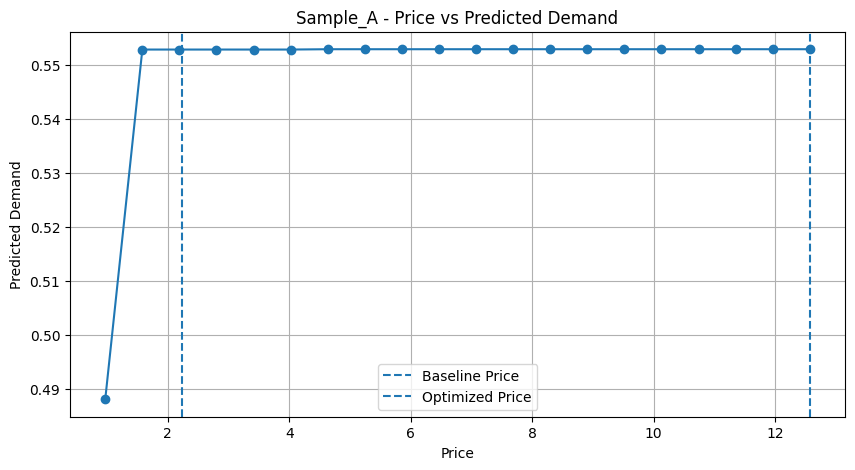

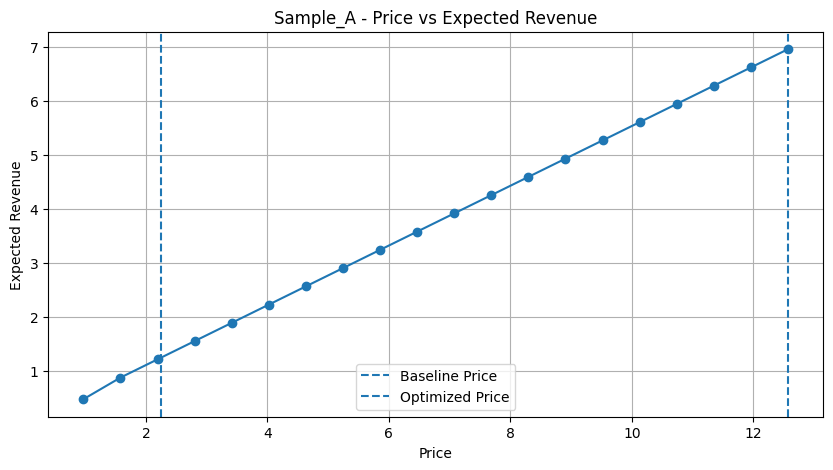

In [ ]:
price_results_A, best_price_A, eval_A = price_optimization_catboost(
    results=results_A,
    df=df_A,
    sample_name="Sample_A",
    price_col="sell_price",
    target_col=TARGET_COL,
    n_prices=20,
    row_index=0,
    price_range_source="local"
)


Price Optimization for Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Selected Optimization Scenario:


,Variable,Value
0,Row_Index,0.000000
1,Original_Price,0.980000
2,Baseline_Predicted_Demand,0.226975
3,Baseline_Revenue,0.222435
4,Actual_Demand,0.000000



Best Price Result:


,19
Sample,Sample_B
Price,10.97
Predicted_Demand,0.228334
Revenue,2.504825
Revenue_vs_Baseline,2.282389
Revenue_Improvement_%,1026.091078
Demand_Retention,1.005988



Price Optimization Evaluation Summary:


,Metric,Value
0,Baseline Price,0.980000
1,Optimized Price,10.970000
2,Baseline Predicted Demand,0.226975
3,Optimized Predicted Demand,0.228334
4,Baseline Revenue,0.222435
5,Optimized Revenue,2.504825
6,Revenue Improvement,2.282389
7,Revenue Improvement (%),1026.091078
8,Demand Retention,1.005988



For Sample_B, the optimized price is 10.97. This produced an expected revenue of 2.505, compared with baseline revenue of 0.222. The revenue improvement is 1026.09%, with demand retention of 1.006.


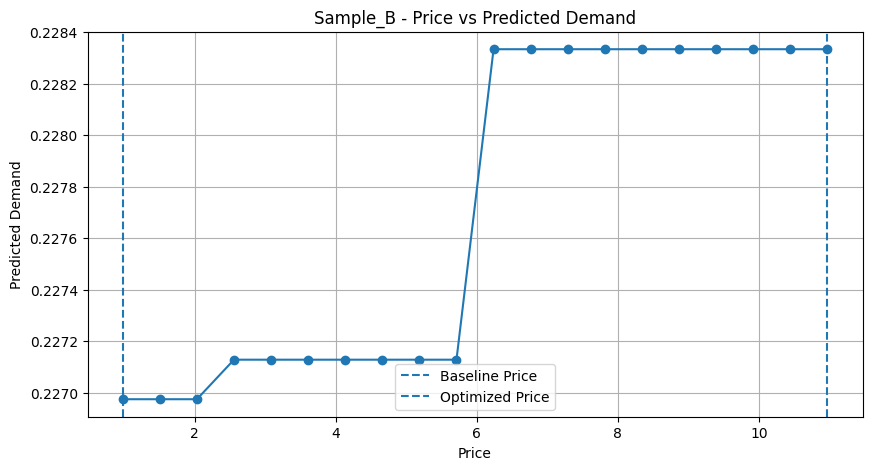

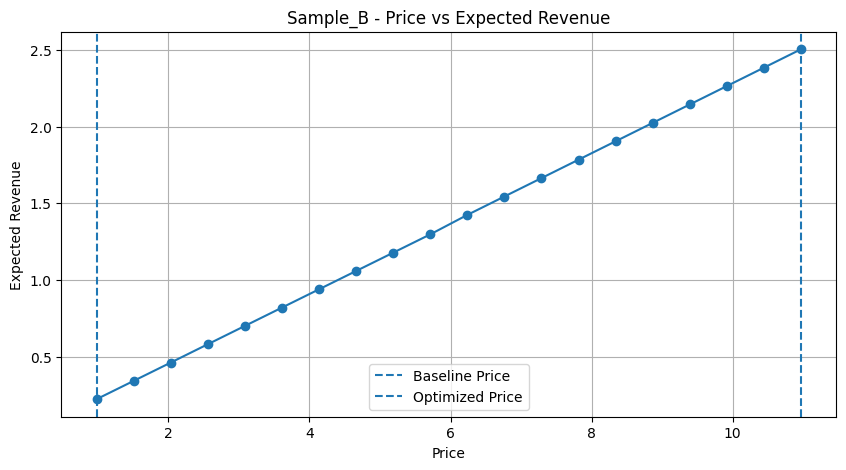

In [ ]:
price_results_B, best_price_B, eval_B = price_optimization_catboost(
    results=results_B,
    df=df_B,
    sample_name="Sample_B",
    price_col="sell_price",
    target_col=TARGET_COL,
    n_prices=20,
    row_index=0,
    price_range_source="local"
)




Price Optimization for Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Selected Optimization Scenario:


,Variable,Value
0,Row_Index,0.000000
1,Original_Price,4.270000
2,Baseline_Predicted_Demand,0.007420
3,Baseline_Revenue,0.031683
4,Actual_Demand,0.000000



Best Price Result:


,19
Sample,Sample_C
Price,10.97
Predicted_Demand,0.00742
Revenue,0.081395
Revenue_vs_Baseline,0.049713
Revenue_Improvement_%,156.908665
Demand_Retention,1.0



Price Optimization Evaluation Summary:


,Metric,Value
0,Baseline Price,4.270000
1,Optimized Price,10.970000
2,Baseline Predicted Demand,0.007420
3,Optimized Predicted Demand,0.007420
4,Baseline Revenue,0.031683
5,Optimized Revenue,0.081395
6,Revenue Improvement,0.049713
7,Revenue Improvement (%),156.908665
8,Demand Retention,1.000000



For Sample_C, the optimized price is 10.97. This produced an expected revenue of 0.081, compared with baseline revenue of 0.032. The revenue improvement is 156.91%, with demand retention of 1.000.


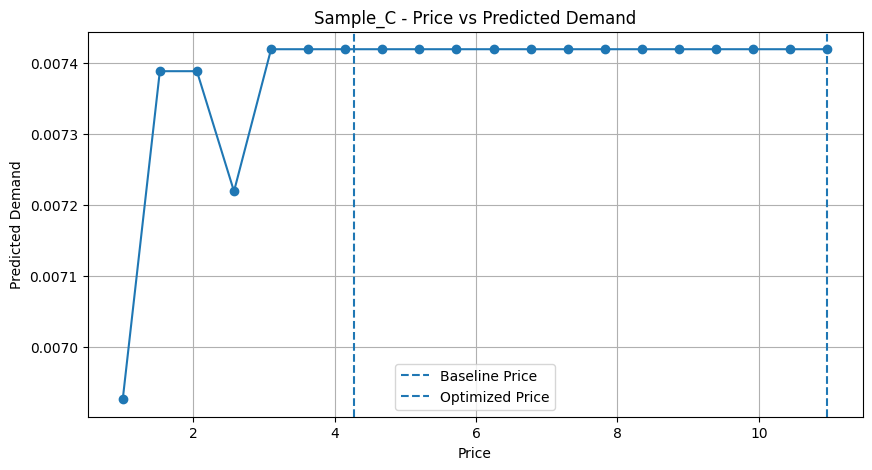

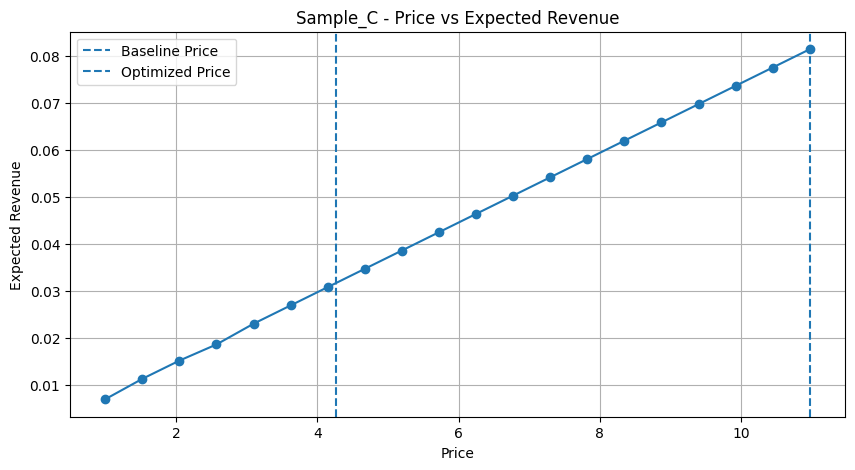

In [ ]:
price_results_C, best_price_C, eval_C = price_optimization_catboost(
    results=results_C,
    df=df_C,
    sample_name="Sample_C",
    price_col="sell_price",
    target_col=TARGET_COL,
    n_prices=20,
    row_index=0,
    price_range_source="local"
)

### Lime for price explanations

In [ ]:
# =====================================================
# LIME Explanation for Price Optimization
# =====================================================

!pip install lime -q

from lime.lime_tabular import LimeTabularExplainer
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def explain_price_optimization_lime_catboost(
    results,
    df,
    best_row,
    sample_name,
    target_col="demand",
    price_col="sell_price",
    row_index=0,
    num_features=10
):
    """
    LIME explanation for the optimized pricing scenario.

    Explains why the CatBoost model predicted the optimized demand.
    """

    print("\n===============================")
    print(f"LIME Price Explanation - {sample_name}")
    print("===============================")

    feature_cols = results["feature_cols"]
    cat_features = results["cat_features"]
    model = results["final_model"]

    # Recreate test set
    _, _, _, _, _, _, _, X_test, y_test = time_based_split(
        df=df,
        target_col=target_col,
        feature_cols=feature_cols
    )

    X_test = X_test.copy()

    # Prepare categorical features
    for col in cat_features:
        if col in X_test.columns:
            X_test[col] = X_test[col].astype(str).fillna("missing")

    # Training data for LIME
    X_train_lime = X_test.copy()

    # Convert categorical columns to category codes
    X_lime_encoded = X_train_lime.copy()

    categorical_indices = []

    for col in cat_features:

        if col in X_lime_encoded.columns:

            categorical_indices.append(
                X_lime_encoded.columns.get_loc(col)
            )

            X_lime_encoded[col] = (
                X_lime_encoded[col]
                .astype("category")
                .cat.codes
            )

    # Base row
    base_row = X_test.iloc[row_index].copy()

    # Replace with optimized price
    base_row[price_col] = best_row["Price"]

    # Encode row
    instance_encoded = base_row.copy()

    for col in cat_features:
        if col in instance_encoded.index:
            instance_encoded[col] = (
                pd.Series([instance_encoded[col]])
                .astype("category")
                .cat.codes[0]
            )

    instance_encoded = instance_encoded.values.astype(float)

    # =====================================================
    # Prediction wrapper
    # =====================================================

    def predict_fn(X_array):

        X_df = pd.DataFrame(
            X_array,
            columns=feature_cols
        )

        # Restore categorical columns
        for col in cat_features:

            if col in X_df.columns:
                X_df[col] = (
                    X_df[col]
                    .round()
                    .astype(int)
                    .astype(str)
                )

        preds = model.predict(X_df)

        return preds.reshape(-1, 1)

    # =====================================================
    # LIME Explainer
    # =====================================================

    explainer = LimeTabularExplainer(
        training_data=X_lime_encoded.values.astype(float),
        feature_names=feature_cols,
        mode="regression",
        categorical_features=categorical_indices,
        discretize_continuous=True
    )

    explanation = explainer.explain_instance(
        data_row=instance_encoded,
        predict_fn=predict_fn,
        num_features=num_features
    )

    # =====================================================
    # Convert to DataFrame
    # =====================================================

    lime_df = pd.DataFrame(
        explanation.as_list(),
        columns=["Feature", "Contribution"]
    )

    lime_df["ABS_Contribution"] = (
        lime_df["Contribution"].abs()
    )

    lime_df = lime_df.sort_values(
        by="ABS_Contribution",
        ascending=False
    ).drop(columns="ABS_Contribution")

    print("\nOptimized Pricing Scenario")
    print(f"Optimized Price: {best_row['Price']:.2f}")
    print(f"Predicted Demand: {best_row['Predicted_Demand']:.3f}")
    print(f"Expected Revenue: {best_row['Revenue']:.3f}")

    print("\nTop Feature Contributions")
    display(lime_df)

    # =====================================================
    # Plot
    # =====================================================

    plt.figure(figsize=(10, 6))

    plt.barh(
        lime_df["Feature"],
        lime_df["Contribution"]
    )

    plt.gca().invert_yaxis()

    plt.xlabel("Contribution to Prediction")
    plt.ylabel("Feature")

    plt.title(
        f"{sample_name} - LIME Explanation for Optimized Price"
    )

    plt.grid(True)

    plt.show()

    return explanation, lime_df

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done



LIME Price Explanation - Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Optimized Pricing Scenario
Optimized Price: 12.57
Predicted Demand: 0.553
Expected Revenue: 6.950

Top Feature Contributions


,Feature,Contribution
0,item_id=0,2.507758
1,0.14 < demand_rolling_mean_7 <= 0.57,-1.425241
2,event_name_1=0,-1.028419
3,price_change_direction <= 0.00,0.591633
4,CAUR > 5.70,0.179727
5,year <= 2015.00,-0.134718
6,state_id=0,-0.127415
7,price_rolling_mean_28 <= 2.28,0.118670
8,price_rolling_std_28 <= 0.00,-0.117900
9,price_change_flag <= 0.00,-0.089099


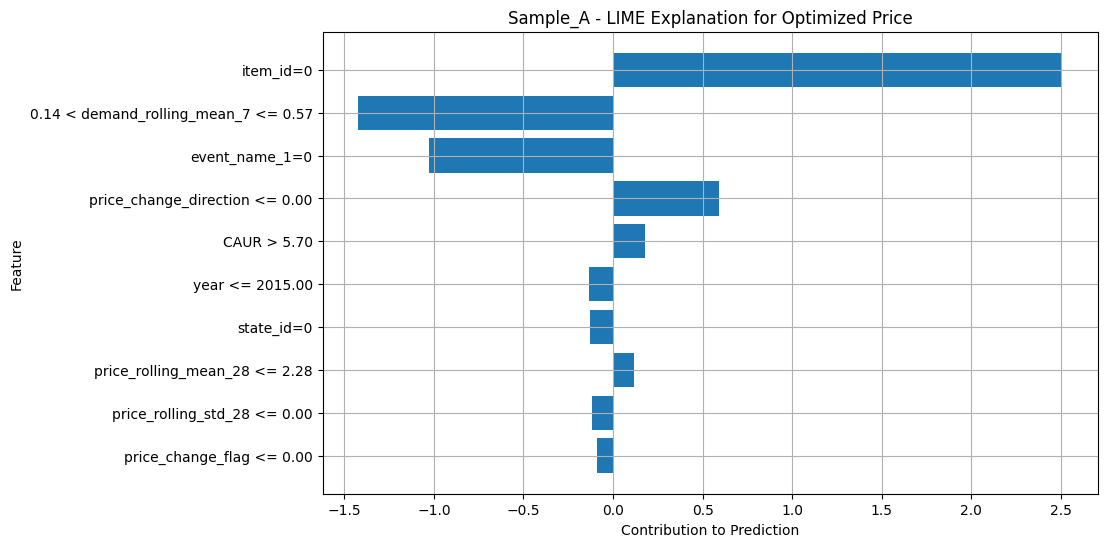

In [ ]:
lime_exp_A, lime_df_A = explain_price_optimization_lime_catboost(
    results=results_A,
    df=df_A,
    best_row=best_price_A,
    sample_name="Sample_A",
    target_col=TARGET_COL,
    price_col="sell_price",
    row_index=0,
    num_features=10
)


LIME Price Explanation - Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Optimized Pricing Scenario
Optimized Price: 10.97
Predicted Demand: 0.228
Expected Revenue: 2.505

Top Feature Contributions


,Feature,Contribution
0,0.14 < demand_rolling_mean_7 <= 0.57,-1.873194
1,item_id=0,1.056922
2,price_change_flag <= 0.00,1.037197
3,price_rolling_std_28 <= 0.00,-0.535043
4,dept_id=0,0.310131
5,2.00 < wday <= 4.00,-0.301189
6,month_year=0,-0.248812
7,event_name_1=0,0.225123
8,0.38 < demand_rolling_std_7 <= 0.76,-0.223412
9,demand_lag_28 <= 0.00,-0.179589


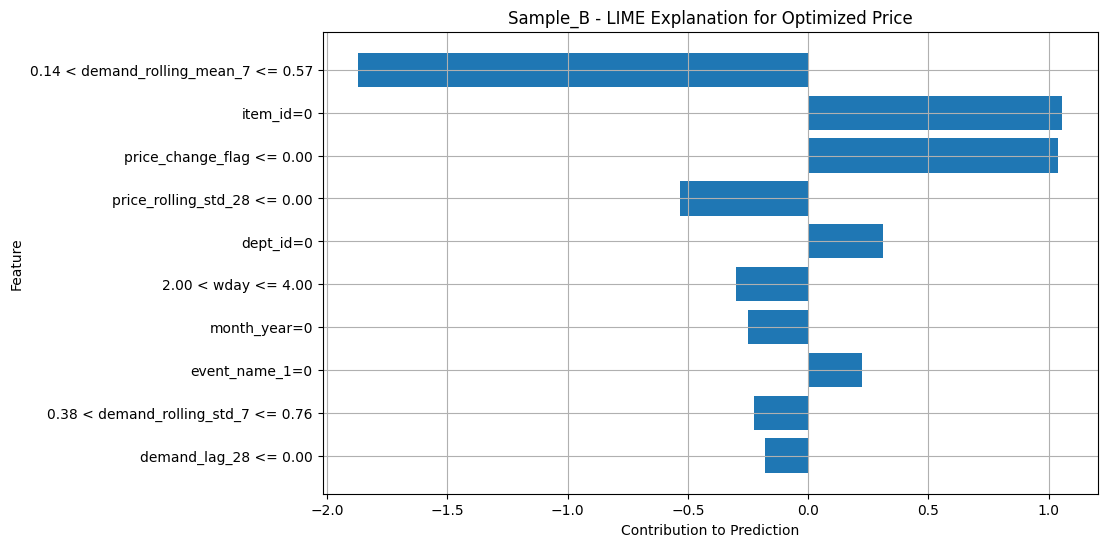

In [ ]:
lime_exp_B, lime_df_B = explain_price_optimization_lime_catboost(
    results=results_B,
    df=df_B,
    best_row=best_price_B,
    sample_name="Sample_B",
    target_col=TARGET_COL,
    price_col="sell_price",
    row_index=0,
    num_features=10
)


LIME Price Explanation - Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Optimized Pricing Scenario
Optimized Price: 10.97
Predicted Demand: 0.007
Expected Revenue: 0.081

Top Feature Contributions


,Feature,Contribution
0,demand_rolling_mean_7 <= 0.14,-1.598669
1,price_change_direction <= 0.00,0.560771
2,price_change_flag <= 0.00,0.481359
3,demand_rolling_std_7 <= 0.38,-0.458510
4,item_id=0,-0.404631
5,event_name_1=0,-0.385405
6,price_rolling_std_28 <= 0.00,0.358038
7,demand_lag_14 <= 0.00,0.297162
8,price_rolling_std_7 <= 0.00,-0.287588
9,dept_id=0,0.147110


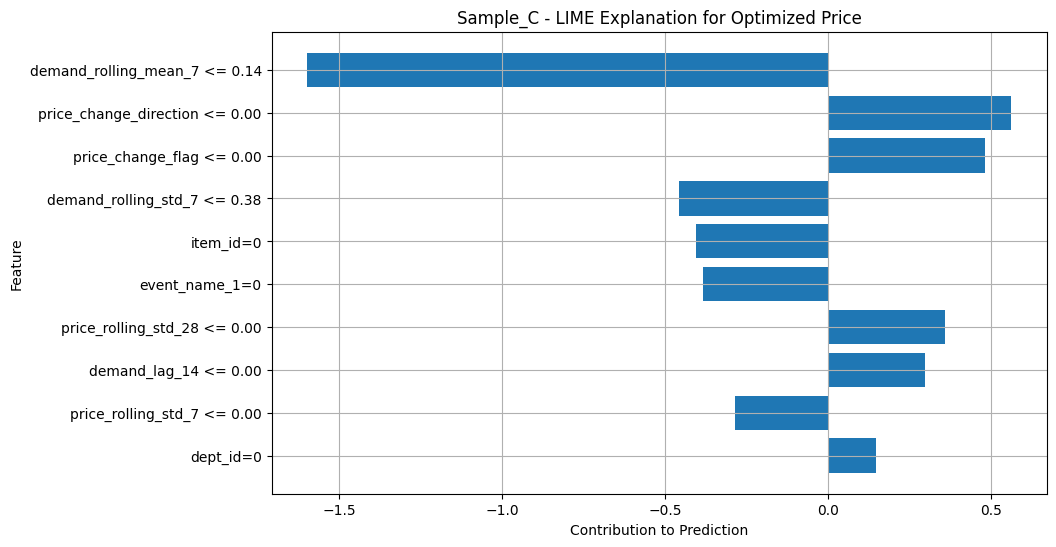

In [ ]:
lime_exp_C, lime_df_C = explain_price_optimization_lime_catboost(
    results=results_C,
    df=df_C,
    best_row=best_price_C,
    sample_name="Sample_C",
    target_col=TARGET_COL,
    price_col="sell_price",
    row_index=0,
    num_features=10
)

## SHAP and LIME Evaluation

###  4. Faithfulness Evaluation

In [ ]:
# =====================================================
# XAI Evaluation: Faithfulness, Robustness, Generalization
# For CatBoost
# =====================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =====================================================
# 1. Prepare Test Data
# =====================================================

def get_catboost_test_data(results, df, target_col="demand"):
    feature_cols = results["feature_cols"]
    cat_features = results["cat_features"]

    _, _, _, _, _, _, _, X_test, y_test = time_based_split(
        df=df,
        target_col=target_col,
        feature_cols=feature_cols
    )

    X_test = X_test.copy()

    for col in cat_features:
        if col in X_test.columns:
            X_test[col] = X_test[col].astype(str).fillna("missing")

    return X_test, y_test


In [ ]:
# =====================================================
# 2. Convert XAI Output to Feature Ranking
# =====================================================

def get_ranked_features(importance_df, feature_cols):
    """
    Works for SHAP and LIME.

    SHAP expected columns:
        Feature, Mean_ABS_SHAP

    LIME expected columns:
        Feature or Feature Condition, Contribution
    """

    df = importance_df.copy()

    if "Mean_ABS_SHAP" in df.columns:
        df["Importance"] = df["Mean_ABS_SHAP"]

    elif "Contribution" in df.columns:
        feature_col = "Feature" if "Feature" in df.columns else "Feature Condition"

        extracted_features = []

        for text in df[feature_col].astype(str):
            matched = None
            for col in feature_cols:
                if col in text:
                    matched = col
                    break
            extracted_features.append(matched)

        df["Feature"] = extracted_features
        df = df.dropna(subset=["Feature"])
        df["Importance"] = df["Contribution"].abs()

        df = (
            df.groupby("Feature", as_index=False)["Importance"]
            .mean()
        )

    else:
        raise ValueError("Importance dataframe format not recognized")

    df = df[["Feature", "Importance"]]
    df = df.sort_values("Importance", ascending=False)

    return df

In [ ]:

# =====================================================
# 3. Mask Features
# =====================================================

def mask_features(
    X,
    features_to_mask,
    cat_features,
    masking_type="mean",
    noise_level=0.05,
    random_state=42
):
    """
    masking_type:
    - mean
    - median
    - permutation
    - noise
    """

    np.random.seed(random_state)

    X_masked = X.copy()

    for col in features_to_mask:

        if col not in X_masked.columns:
            continue

        if col in cat_features:
            # For categorical variables, use most frequent value
            mode_value = X_masked[col].mode()[0]
            X_masked[col] = mode_value

        else:
            if masking_type == "mean":
                X_masked[col] = X_masked[col].mean()

            elif masking_type == "median":
                X_masked[col] = X_masked[col].median()

            elif masking_type == "permutation":
                X_masked[col] = np.random.permutation(X_masked[col].values)

            elif masking_type == "noise":
                std = X_masked[col].std()
                noise = np.random.normal(
                    loc=0,
                    scale=noise_level * std,
                    size=len(X_masked)
                )
                X_masked[col] = X_masked[col] + noise

            else:
                raise ValueError("masking_type must be mean, median, permutation, or noise")

    return X_masked


In [ ]:
# =====================================================
# 4. Faithfulness Evaluation
# =====================================================

def evaluate_faithfulness_catboost(
    results,
    df,
    importance_df,
    sample_name,
    xai_method_name,
    target_col="demand",
    top_k=5,
    masking_type="mean",
    n_samples=1000
):
    """
    Faithfulness:
    - Mask most important features
    - Mask least important features
    - Compare performance degradation
    """

    print("\n===============================")
    print(f"Faithfulness Evaluation: {xai_method_name} - {sample_name}")
    print("===============================")

    model = results["final_model"]
    feature_cols = results["feature_cols"]
    cat_features = results["cat_features"]

    X_test, y_test = get_catboost_test_data(
        results=results,
        df=df,
        target_col=target_col
    )

    X_test = X_test.iloc[:n_samples].copy()
    y_test = y_test.iloc[:n_samples].copy()

    ranked_df = get_ranked_features(
        importance_df=importance_df,
        feature_cols=feature_cols
    )

    most_important = ranked_df.head(top_k)["Feature"].tolist()
    least_important = ranked_df.tail(top_k)["Feature"].tolist()

    # Original prediction
    y_pred_original = model.predict(X_test)
    y_pred_original = np.maximum(y_pred_original, 0)

    original_rmse = np.sqrt(mean_squared_error(y_test, y_pred_original))
    original_mae = mean_absolute_error(y_test, y_pred_original)
    original_r2 = r2_score(y_test, y_pred_original)

    results_list = []

    for mask_group, features_to_mask in {
        "Most Important Masking": most_important,
        "Least Important Masking": least_important
    }.items():

        X_masked = mask_features(
            X=X_test,
            features_to_mask=features_to_mask,
            cat_features=cat_features,
            masking_type=masking_type
        )

        y_pred_masked = model.predict(X_masked)
        y_pred_masked = np.maximum(y_pred_masked, 0)

        masked_rmse = np.sqrt(mean_squared_error(y_test, y_pred_masked))
        masked_mae = mean_absolute_error(y_test, y_pred_masked)
        masked_r2 = r2_score(y_test, y_pred_masked)

        prediction_change = np.mean(
            np.abs(y_pred_original - y_pred_masked)
        )

        results_list.append({
            "Sample": sample_name,
            "XAI_Method": xai_method_name,
            "Masking_Group": mask_group,
            "Masking_Type": masking_type,
            "Top_K": top_k,
            "Masked_Features": ", ".join(features_to_mask),
            "Original_RMSE": original_rmse,
            "Masked_RMSE": masked_rmse,
            "RMSE_Increase": masked_rmse - original_rmse,
            "Original_MAE": original_mae,
            "Masked_MAE": masked_mae,
            "MAE_Increase": masked_mae - original_mae,
            "Original_R2": original_r2,
            "Masked_R2": masked_r2,
            "R2_Drop": original_r2 - masked_r2,
            "Mean_Prediction_Change": prediction_change
        })

    faithfulness_df = pd.DataFrame(results_list)

    display(faithfulness_df)

    return faithfulness_df

### Fithfulness (Fidality Evaluation)

In [ ]:
faith_shap_A = evaluate_faithfulness_catboost(
    results=results_A,
    df=df_A,
    importance_df=shap_features_A,
    sample_name="Sample_A",
    xai_method_name="SHAP",
    target_col=TARGET_COL,
    top_k=5,
    masking_type="mean"
)

faith_shap_B = evaluate_faithfulness_catboost(
    results=results_B,
    df=df_B,
    importance_df=shap_features_B,
    sample_name="Sample_B",
    xai_method_name="SHAP",
    target_col=TARGET_COL,
    top_k=5,
    masking_type="mean"
)

faith_shap_C = evaluate_faithfulness_catboost(
    results=results_C,
    df=df_C,
    importance_df=shap_features_C,
    sample_name="Sample_C",
    xai_method_name="SHAP",
    target_col=TARGET_COL,
    top_k=5,
    masking_type="mean"
)



Faithfulness Evaluation: SHAP - Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


,Sample,XAI_Method,Masking_Group,Masking_Type,Top_K,Masked_Features,Original_RMSE,Masked_RMSE,RMSE_Increase,Original_MAE,Masked_MAE,MAE_Increase,Original_R2,Masked_R2,R2_Drop,Mean_Prediction_Change
0,Sample_A,SHAP,Most Important Masking,mean,5,"demand_rolling_mean_7, demand_rolling_std_7, d...",1.169621,1.958563,0.788942,0.673765,1.183943,0.510178,0.649464,0.017082,0.632382,1.042438
1,Sample_A,SHAP,Least Important Masking,mean,5,"price_change_flag, CPIAUCSL, CAUR, price_chang...",1.169621,1.169621,0.000000,0.673765,0.673765,0.000000,0.649464,0.649464,0.000000,0.000000



Faithfulness Evaluation: SHAP - Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


,Sample,XAI_Method,Masking_Group,Masking_Type,Top_K,Masked_Features,Original_RMSE,Masked_RMSE,RMSE_Increase,Original_MAE,Masked_MAE,MAE_Increase,Original_R2,Masked_R2,R2_Drop,Mean_Prediction_Change
0,Sample_B,SHAP,Most Important Masking,mean,5,"demand_rolling_mean_7, demand_rolling_std_7, d...",1.50375,2.247733,0.743983,0.746877,1.313076,0.5662,0.561436,0.020124,0.541312,1.099288
1,Sample_B,SHAP,Least Important Masking,mean,5,"WIUR, event_name_2, price_change_flag, UNRATE,...",1.50375,1.503750,0.000000,0.746877,0.746877,0.0000,0.561436,0.561436,0.000000,0.000000



Faithfulness Evaluation: SHAP - Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


,Sample,XAI_Method,Masking_Group,Masking_Type,Top_K,Masked_Features,Original_RMSE,Masked_RMSE,RMSE_Increase,Original_MAE,Masked_MAE,MAE_Increase,Original_R2,Masked_R2,R2_Drop,Mean_Prediction_Change
0,Sample_C,SHAP,Most Important Masking,mean,5,"demand_rolling_mean_7, demand_rolling_std_7, d...",1.167626,1.749511,0.581885,0.674255,1.167712,0.493457,0.556406,0.004111,0.552295,0.988469
1,Sample_C,SHAP,Least Important Masking,mean,5,"CPIUFDSL, sell_price, price_change_flag, price...",1.167626,1.167511,-0.000115,0.674255,0.674230,-0.000025,0.556406,0.556494,-0.000087,0.000240


In [ ]:
# =====================================================
# LIME Faithfulness Evaluation
# Samples A, B, C
# =====================================================

faith_lime_A = evaluate_faithfulness_catboost(
    results=results_A,
    df=df_A,
    importance_df=lime_df_A,
    sample_name="Sample_A",
    xai_method_name="LIME",
    target_col=TARGET_COL,
    top_k=5,
    masking_type="mean"
)

faith_lime_B = evaluate_faithfulness_catboost(
    results=results_B,
    df=df_B,
    importance_df=lime_df_B,
    sample_name="Sample_B",
    xai_method_name="LIME",
    target_col=TARGET_COL,
    top_k=5,
    masking_type="mean"
)

faith_lime_C = evaluate_faithfulness_catboost(
    results=results_C,
    df=df_C,
    importance_df=lime_df_C,
    sample_name="Sample_C",
    xai_method_name="LIME",
    target_col=TARGET_COL,
    top_k=5,
    masking_type="mean"
)


Faithfulness Evaluation: LIME - Sample_A
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


,Sample,XAI_Method,Masking_Group,Masking_Type,Top_K,Masked_Features,Original_RMSE,Masked_RMSE,RMSE_Increase,Original_MAE,Masked_MAE,MAE_Increase,Original_R2,Masked_R2,R2_Drop,Mean_Prediction_Change
0,Sample_A,LIME,Most Important Masking,mean,5,"item_id, demand_rolling_mean_7, event_name_1, ...",1.169621,1.886058,0.716437,0.673765,1.066443,0.392678,0.649464,0.088510,0.560955,0.895033
1,Sample_A,LIME,Least Important Masking,mean,5,"year, state_id, price_rolling_mean_28, price_r...",1.169621,1.170814,0.001193,0.673765,0.674027,0.000262,0.649464,0.648749,0.000716,0.000963



Faithfulness Evaluation: LIME - Sample_B
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


,Sample,XAI_Method,Masking_Group,Masking_Type,Top_K,Masked_Features,Original_RMSE,Masked_RMSE,RMSE_Increase,Original_MAE,Masked_MAE,MAE_Increase,Original_R2,Masked_R2,R2_Drop,Mean_Prediction_Change
0,Sample_B,LIME,Most Important Masking,mean,5,"demand_rolling_mean_7, item_id, price_change_f...",1.50375,2.212192,0.708442,0.746877,1.183149,0.436273,0.561436,0.050867,0.510569,0.943337
1,Sample_B,LIME,Least Important Masking,mean,5,"wday, month, event_name_1, demand_rolling_std_...",1.50375,1.563994,0.060244,0.746877,0.831529,0.084653,0.561436,0.525592,0.035844,0.111621



Faithfulness Evaluation: LIME - Sample_C
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


,Sample,XAI_Method,Masking_Group,Masking_Type,Top_K,Masked_Features,Original_RMSE,Masked_RMSE,RMSE_Increase,Original_MAE,Masked_MAE,MAE_Increase,Original_R2,Masked_R2,R2_Drop,Mean_Prediction_Change
0,Sample_C,LIME,Most Important Masking,mean,5,"demand_rolling_mean_7, price_change_direction,...",1.167626,1.751014,0.583388,0.674255,1.148235,0.473980,0.556406,0.002399,0.554007,0.961875
1,Sample_C,LIME,Least Important Masking,mean,5,"event_name_1, price_rolling_std_28, demand_lag...",1.167626,1.171060,0.003434,0.674255,0.682173,0.007918,0.556406,0.553793,0.002613,0.031533


### Robustness (Stability)

In [ ]:
def add_noise_to_data(
    X,
    cat_features,
    noise_level=0.05,
    random_state=42
):
    """
    Add Gaussian noise to numeric features only.

    Used for:
    - SHAP robustness
    - LIME robustness
    - PDP robustness
    """

    np.random.seed(random_state)

    X_noisy = X.copy()

    # Select only numeric columns that are not identified as categorical
    numeric_cols = [
        col for col in X_noisy.columns
        if col not in cat_features and pd.api.types.is_numeric_dtype(X_noisy[col])
    ]

    for col in numeric_cols:

        std = X_noisy[col].std()

        if std == 0 or pd.isna(std):
            continue

        noise = np.random.normal(
            loc=0,
            scale=noise_level * std,
            size=len(X_noisy)
        )

        X_noisy[col] = X_noisy[col] + noise

    return X_noisy

In [ ]:
# =====================================================
# Robustness Evaluation for SHAP / LIME
# =====================================================

from scipy.stats import spearmanr
import pandas as pd

def evaluate_xai_robustness(
    original_importance_df,
    noisy_importance_df,
    feature_cols,
    sample_name,
    xai_method_name,
    top_k=10
):
    """
    General robustness evaluation for any XAI method.

    Compares original feature importance with noisy feature importance.
    Works for SHAP and LIME as long as both are converted to ranked features.
    """

    original_ranked = get_ranked_features(
        original_importance_df,
        feature_cols
    ).rename(columns={"Importance": "Original_Importance"})

    noisy_ranked = get_ranked_features(
        noisy_importance_df,
        feature_cols
    ).rename(columns={"Importance": "Noisy_Importance"})

    compare_df = original_ranked.merge(
        noisy_ranked,
        on="Feature"
    )

    corr, p_value = spearmanr(
        compare_df["Original_Importance"],
        compare_df["Noisy_Importance"]
    )

    original_top = set(original_ranked.head(top_k)["Feature"])
    noisy_top = set(noisy_ranked.head(top_k)["Feature"])

    topk_overlap = len(original_top.intersection(noisy_top)) / top_k

    robustness_df = pd.DataFrame({
        "Sample": [sample_name],
        "XAI_Method": [xai_method_name],
        "Spearman_Correlation": [corr],
        "p_value": [p_value],
        "Top_K": [top_k],
        "Top_K_Overlap": [topk_overlap]
    })

    display(robustness_df)

    return robustness_df, compare_df

In [ ]:
# =====================================================
# Create Noisy Test Data
# =====================================================dont run this code next time

X_test_A, y_test_A = get_catboost_test_data(
    results_A,
    df_A,
    TARGET_COL
)

X_test_B, y_test_B = get_catboost_test_data(
    results_B,
    df_B,
    TARGET_COL
)

X_test_C, y_test_C = get_catboost_test_data(
    results_C,
    df_C,
    TARGET_COL
)

X_noisy_A = add_noise_to_data(
    X_test_A,
    results_A["cat_features"],
    noise_level=0.05
)

X_noisy_B = add_noise_to_data(
    X_test_B,
    results_B["cat_features"],
    noise_level=0.05
)

X_noisy_C = add_noise_to_data(
    X_test_C,
    results_C["cat_features"],
    noise_level=0.05
)

Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)


Generate Explanations

In [ ]:
explainer_A = shap.TreeExplainer(results_A["final_model"])

shap_values_noisy_A = explainer_A.shap_values(X_noisy_A)

shap_noisy_A = pd.DataFrame({
    "Feature": results_A["feature_cols"],
    "Mean_ABS_SHAP": np.mean(np.abs(shap_values_noisy_A), axis=0)
})
explainer_B = shap.TreeExplainer(results_B["final_model"])

shap_values_noisy_B = explainer_A.shap_values(X_noisy_B)

shap_noisy_B = pd.DataFrame({
    "Feature": results_B["feature_cols"],
    "Mean_ABS_SHAP": np.mean(np.abs(shap_values_noisy_B), axis=0)
})
explainer_C = shap.TreeExplainer(results_C["final_model"])

shap_values_noisy_C = explainer_A.shap_values(X_noisy_C)

shap_noisy_C = pd.DataFrame({
    "Feature": results_C["feature_cols"],
    "Mean_ABS_SHAP": np.mean(np.abs(shap_values_noisy_C), axis=0)
})



LIME Price Explanation - Sample_A_Noisy
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Optimized Pricing Scenario
Optimized Price: 12.57
Predicted Demand: 0.553
Expected Revenue: 6.950

Top Feature Contributions


,Feature,Contribution
0,0.14 < demand_rolling_mean_7 <= 0.57,-1.518638
1,price_change_flag <= 0.00,-0.524471
2,price_change_direction <= 0.00,0.504699
3,price_rolling_std_7 <= 0.00,0.395095
4,price_lag_1 <= 2.28,0.136728
5,0.00 < snap_CA <= 1.00,-0.127945
6,item_id=0,0.109910
7,CAUR > 5.70,-0.102617
8,event_type_1=0,-0.101583
9,event_name_1=0,-0.089778


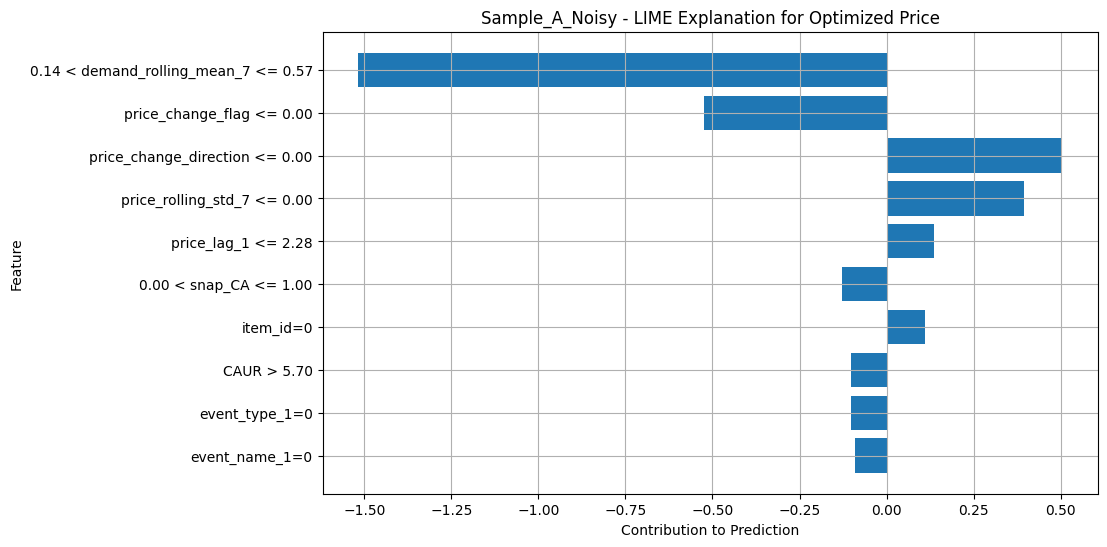


LIME Price Explanation - Sample_A_Noisy
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Optimized Pricing Scenario
Optimized Price: 10.97
Predicted Demand: 0.228
Expected Revenue: 2.505

Top Feature Contributions


,Feature,Contribution
0,0.14 < demand_rolling_mean_7 <= 0.57,-1.922786
1,price_change_flag <= 0.00,-1.113244
2,event_name_1=0,0.680647
3,CAUR > 5.70,-0.448246
4,0.38 < demand_rolling_std_7 <= 0.76,-0.351288
5,price_change_direction <= 0.00,-0.294349
6,2.00 < wday <= 4.00,-0.270074
7,-0.30 < UMCSENT_diff <= 1.30,-0.207094
8,event_type_1=0,-0.185887
9,dept_id=0,0.171953


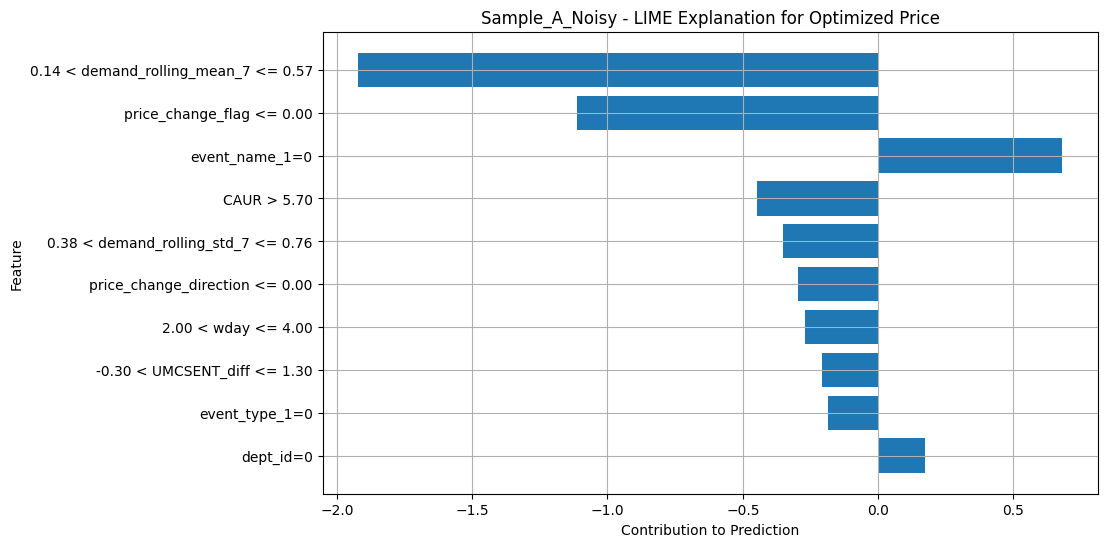


LIME Price Explanation - Sample_A_Noisy
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)

Optimized Pricing Scenario
Optimized Price: 10.97
Predicted Demand: 0.007
Expected Revenue: 0.081

Top Feature Contributions


,Feature,Contribution
0,demand_rolling_mean_7 <= 0.14,-1.648036
1,price_change_flag <= 0.00,-0.605536
2,price_rolling_std_7 <= 0.00,-0.597627
3,event_name_1=0,-0.515344
4,demand_rolling_std_7 <= 0.38,-0.392530
5,item_id=0,-0.302097
6,demand_lag_14 <= 0.00,0.243107
7,3.50 < price_rolling_mean_7 <= 5.94,-0.171359
8,dept_id=0,-0.166236
9,0.00 < snap_CA <= 1.00,-0.147277


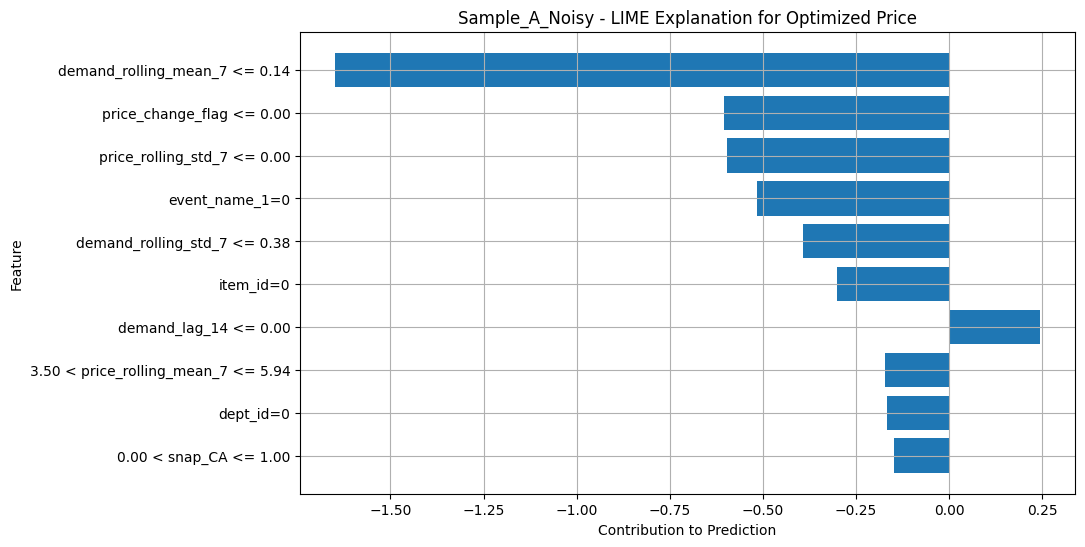

In [ ]:
_, lime_noisy_A = explain_price_optimization_lime_catboost(
    results=results_A,
    df=df_A,
    best_row=best_price_A,
    sample_name="Sample_A_Noisy",
    target_col=TARGET_COL,
    row_index=0
)
_, lime_noisy_B = explain_price_optimization_lime_catboost(
    results=results_B,
    df=df_B,
    best_row=best_price_B,
    sample_name="Sample_A_Noisy",
    target_col=TARGET_COL,
    row_index=0
)
_, lime_noisy_C = explain_price_optimization_lime_catboost(
    results=results_C,
    df=df_C,
    best_row=best_price_C,
    sample_name="Sample_A_Noisy",
    target_col=TARGET_COL,
    row_index=0
)

Run Evaluation

In [ ]:
robust_shap_A, shap_compare_ = evaluate_xai_robustness(
    original_importance_df=shap_features_A,
    noisy_importance_df=shap_noisy_A,
    feature_cols=results_A["feature_cols"],
    sample_name="Sample_A",
    xai_method_name="SHAP"
)
robust_shap_B, shap_compare_B = evaluate_xai_robustness(
    original_importance_df=shap_features_B,
    noisy_importance_df=shap_noisy_B,
    feature_cols=results_B["feature_cols"],
    sample_name="Sample_B",
    xai_method_name="SHAP"
)
obust_shap_C, shap_compare_C = evaluate_xai_robustness(
    original_importance_df=shap_features_C,
    noisy_importance_df=shap_noisy_C,
    feature_cols=results_C["feature_cols"],
    sample_name="Sample_C",
    xai_method_name="SHAP"
)


,Sample,XAI_Method,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,Sample_A,SHAP,0.909486,5.382288e-18,10,0.9


,Sample,XAI_Method,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,Sample_B,SHAP,0.692885,1.332177e-07,10,0.5


,Sample,XAI_Method,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,Sample_C,SHAP,0.742819,5.144155e-09,10,0.6


In [ ]:
robust_lime_A, lime_compare_A = evaluate_xai_robustness(
    original_importance_df=lime_df_A,
    noisy_importance_df=lime_noisy_A,
    feature_cols=results_A["feature_cols"],
    sample_name="Sample_A",
    xai_method_name="LIME",
    top_k=10
)
robust_lime_B, lime_compare_B = evaluate_xai_robustness(
    original_importance_df=lime_df_B,
    noisy_importance_df=lime_noisy_B,
    feature_cols=results_B["feature_cols"],
    sample_name="Sample_B",
    xai_method_name="LIME",
    top_k=10
)
robust_lime_C, lime_compare_C= evaluate_xai_robustness(
    original_importance_df=lime_df_C,
    noisy_importance_df=lime_noisy_C,
    feature_cols=results_C["feature_cols"],
    sample_name="Sample_C",
    xai_method_name="LIME",
    top_k=10
)

,Sample,XAI_Method,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,Sample_A,LIME,-0.028571,0.957155,10,0.6


,Sample,XAI_Method,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,Sample_B,LIME,0.485714,0.328723,10,0.6


,Sample,XAI_Method,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,Sample_C,LIME,0.690476,0.05799,10,0.8


### Generalization

In [ ]:
# =====================================================
# 6. Generalization Across Samples
# =====================================================

def evaluate_generalization_across_samples(
    importance_A,
    importance_B,
    importance_C,
    feature_cols,
    xai_method_name="SHAP",
    top_k=10
):
    """
    Compare feature importance rankings across Sample A, B, and C.
    """

    A = get_ranked_features(importance_A, feature_cols).rename(
        columns={"Importance": "Sample_A_Importance"}
    )

    B = get_ranked_features(importance_B, feature_cols).rename(
        columns={"Importance": "Sample_B_Importance"}
    )

    C = get_ranked_features(importance_C, feature_cols).rename(
        columns={"Importance": "Sample_C_Importance"}
    )

    compare_df = A.merge(B, on="Feature").merge(C, on="Feature")

    comparisons = [
        ("Sample A vs Sample B", "Sample_A_Importance", "Sample_B_Importance"),
        ("Sample A vs Sample C", "Sample_A_Importance", "Sample_C_Importance"),
        ("Sample B vs Sample C", "Sample_B_Importance", "Sample_C_Importance")
    ]

    results_list = []

    for name, col1, col2 in comparisons:

        corr, p_value = spearmanr(
            compare_df[col1],
            compare_df[col2]
        )

        top_1 = set(
            compare_df.sort_values(col1, ascending=False)
            .head(top_k)["Feature"]
        )

        top_2 = set(
            compare_df.sort_values(col2, ascending=False)
            .head(top_k)["Feature"]
        )

        topk_overlap = len(top_1.intersection(top_2)) / top_k

        results_list.append({
            "XAI_Method": xai_method_name,
            "Comparison": name,
            "Spearman_Correlation": corr,
            "p_value": p_value,
            "Top_K": top_k,
            "Top_K_Overlap": topk_overlap
        })

    generalization_df = pd.DataFrame(results_list)

    display(generalization_df)

    return generalization_df, compare_df

In [ ]:
generalization_shap_df, shap_compare_df = evaluate_generalization_across_samples(
    importance_A=shap_features_A,
    importance_B=shap_features_B,
    importance_C=shap_features_C,
    feature_cols=results_A["feature_cols"],
    xai_method_name="SHAP",
    top_k=10
)

,XAI_Method,Comparison,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,SHAP,Sample A vs Sample B,0.644137,1.803986e-06,10,0.7
1,SHAP,Sample A vs Sample C,0.758366,1.598342e-09,10,0.6
2,SHAP,Sample B vs Sample C,0.800791,3.995197e-11,10,0.8


In [ ]:
# =====================================================
# LIME Generalization Across Samples
# =====================================================

generalization_lime_df, lime_compare_df = evaluate_generalization_across_samples(
    importance_A=lime_df_A,
    importance_B=lime_df_B,
    importance_C=lime_df_C,
    feature_cols=results_A["feature_cols"],
    xai_method_name="LIME",
    top_k=10
)

display(generalization_lime_df)

,XAI_Method,Comparison,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,LIME,Sample A vs Sample B,0.5,0.391002,10,0.5
1,LIME,Sample A vs Sample C,0.2,0.747060,10,0.5
2,LIME,Sample B vs Sample C,0.8,0.104088,10,0.5


,XAI_Method,Comparison,Spearman_Correlation,p_value,Top_K,Top_K_Overlap
0,LIME,Sample A vs Sample B,0.5,0.391002,10,0.5
1,LIME,Sample A vs Sample C,0.2,0.747060,10,0.5
2,LIME,Sample B vs Sample C,0.8,0.104088,10,0.5


## PDP Evaluation

### 1. PDP Faithfulness

In [ ]:
# =====================================================
# PDP Evaluation for CatBoost
# Faithfulness, Robustness, Generalization
# =====================================================

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import auc

# =====================================================
# 1. PDP Faithfulness
# =====================================================

def evaluate_pdp_faithfulness(
    pdp_df,
    feature_name,
    sample_name
):
    """
    PDP faithfulness is evaluated using prediction sensitivity.
    Higher change in predicted demand means stronger PDP sensitivity.
    """

    y = pdp_df["Average_Predicted_Demand"].values

    prediction_range = y.max() - y.min()
    prediction_std = y.std()
    auc_value = auc(
        pdp_df[feature_name].values,
        y
    )

    faithfulness_df = pd.DataFrame({
        "Sample": [sample_name],
        "Feature": [feature_name],
        "PDP_Prediction_Range": [prediction_range],
        "PDP_Prediction_STD": [prediction_std],
        "PDP_AUC": [auc_value]
    })

    display(faithfulness_df)

    return faithfulness_df

In [ ]:
pdp_faith_price_A = evaluate_pdp_faithfulness(
    pdp_df=price_sensitivity_A,
    feature_name="sell_price",
    sample_name="Sample_A"
)

pdp_faith_price_B = evaluate_pdp_faithfulness(
    pdp_df=price_sensitivity_B,
    feature_name="sell_price",
    sample_name="Sample_B"
)

pdp_faith_price_C = evaluate_pdp_faithfulness(
    pdp_df=price_sensitivity_C,
    feature_name="sell_price",
    sample_name="Sample_C"
)

,Sample,Feature,PDP_Prediction_Range,PDP_Prediction_STD,PDP_AUC
0,Sample_A,sell_price,0.044842,0.009771,23.422529


,Sample,Feature,PDP_Prediction_Range,PDP_Prediction_STD,PDP_AUC
0,Sample_B,sell_price,0.029018,0.00629,30.420562


,Sample,Feature,PDP_Prediction_Range,PDP_Prediction_STD,PDP_AUC
0,Sample_C,sell_price,0.005818,0.001266,18.661756


###  2. PDP Robustness

In [ ]:
# =====================================================
# 2. PDP Robustness
# =====================================================

def evaluate_pdp_robustness(
    original_pdp_df,
    noisy_pdp_df,
    feature_name,
    sample_name
):
    """
    Compare original PDP curve with noisy PDP curve.
    """

    original_y = original_pdp_df["Average_Predicted_Demand"].values
    noisy_y = noisy_pdp_df["Average_Predicted_Demand"].values

    spearman_corr, spearman_p = spearmanr(original_y, noisy_y)
    pearson_corr, pearson_p = pearsonr(original_y, noisy_y)

    auc_original = auc(
        original_pdp_df[feature_name].values,
        original_y
    )

    auc_noisy = auc(
        noisy_pdp_df[feature_name].values,
        noisy_y
    )

    auc_difference = abs(auc_original - auc_noisy)

    robustness_df = pd.DataFrame({
        "Sample": [sample_name],
        "Feature": [feature_name],
        "Spearman_Correlation": [spearman_corr],
        "Spearman_p_value": [spearman_p],
        "Pearson_Correlation": [pearson_corr],
        "Pearson_p_value": [pearson_p],
        "Original_AUC": [auc_original],
        "Noisy_AUC": [auc_noisy],
        "AUC_Difference": [auc_difference]
    })

    display(robustness_df)

    return robustness_df

In [ ]:
df_A_noisy = add_noise_to_data(
    X=df_A,
    cat_features=results_A["cat_features"],
    noise_level=0.05
)
df_B_noisy = add_noise_to_data(
    X=df_B,
    cat_features=results_B["cat_features"],
    noise_level=0.05
)

df_C_noisy = add_noise_to_data(
    X=df_C,
    cat_features=results_C["cat_features"],
    noise_level=0.05
)

PDP Analysis for Sample_A_Noisy
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: sell_price
Range source used: local
Range: -0.0782922022462767 -> 22.63897749550145


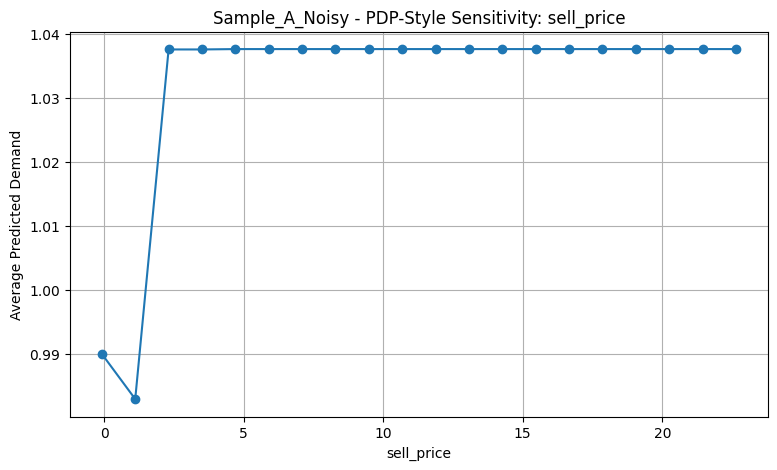

,sell_price,Average_Predicted_Demand
0,-0.078292,0.990020
1,1.117354,0.982977
2,2.312999,1.037534
3,3.508645,1.037534
4,4.704291,1.037592
5,5.899937,1.037592
6,7.095582,1.037592
7,8.291228,1.037592
8,9.486874,1.037592
9,10.682520,1.037592


PDP Analysis for Sample_B_Noisy
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: sell_price
Range source used: local
Range: 0.2663379517514699 -> 27.098715859703677


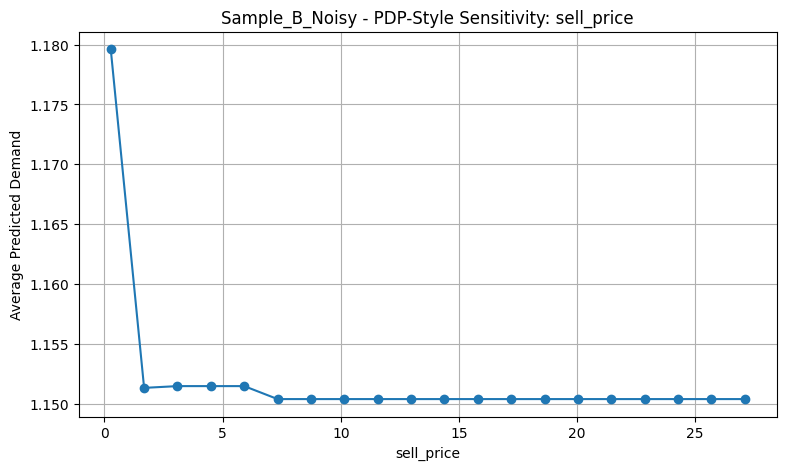

,sell_price,Average_Predicted_Demand
0,0.266338,1.179623
1,1.678568,1.151308
2,3.090799,1.151455
3,4.503029,1.151455
4,5.915260,1.151455
5,7.327490,1.150371
6,8.739720,1.150371
7,10.151951,1.150371
8,11.564181,1.150371
9,12.976412,1.150371


PDP Analysis for Sample_C_Noisy
Train shape: (516040, 45)
Validation shape: (147440, 45)
Test shape: (74100, 45)
Feature: sell_price
Range source used: local
Range: 0.37620618367478875 -> 18.71220622651845


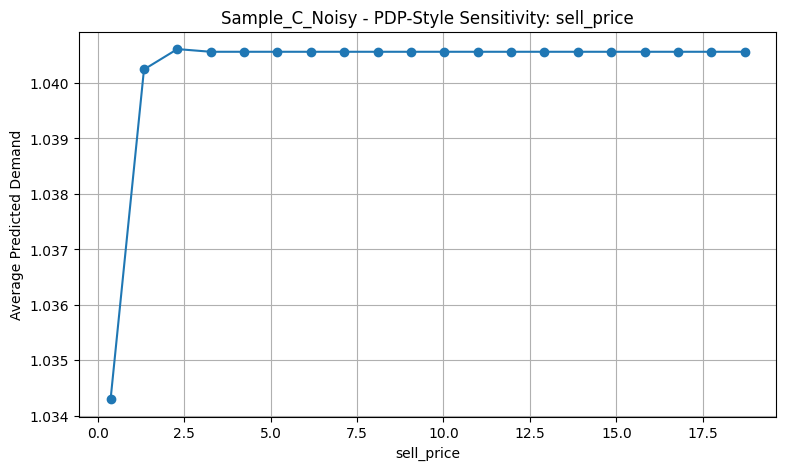

,sell_price,Average_Predicted_Demand
0,0.376206,1.034298
1,1.341259,1.040245
2,2.306311,1.040613
3,3.271364,1.040564
4,4.236417,1.040564
5,5.201469,1.040564
6,6.166522,1.040564
7,7.131575,1.040564
8,8.096627,1.040564
9,9.061680,1.040564


In [ ]:
price_sensitivity_A_noisy = catboost_sensitivity_plot(
    results=results_A,
    df=df_A_noisy,
    feature_name="sell_price",
    sample_name="Sample_A_Noisy",
    target_col=TARGET_COL,
    range_source="local"
)
price_sensitivity_B_noisy = catboost_sensitivity_plot(
    results=results_B,
    df=df_B_noisy,
    feature_name="sell_price",
    sample_name="Sample_B_Noisy",
    target_col=TARGET_COL,
    range_source="local"
)
price_sensitivity_C_noisy = catboost_sensitivity_plot(
    results=results_C,
    df=df_C_noisy,
    feature_name="sell_price",
    sample_name="Sample_C_Noisy",
    target_col=TARGET_COL,
    range_source="local"
)

In [ ]:
pdp_robust_price_A = evaluate_pdp_robustness(
    original_pdp_df=price_sensitivity_A,
    noisy_pdp_df=price_sensitivity_A_noisy,
    feature_name="sell_price",
    sample_name="Sample_A"
)

pdp_robust_price_B = evaluate_pdp_robustness(
    original_pdp_df=price_sensitivity_B,
    noisy_pdp_df=price_sensitivity_B_noisy,
    feature_name="sell_price",
    sample_name="Sample_B"
)

pdp_robust_price_C = evaluate_pdp_robustness(
    original_pdp_df=price_sensitivity_C,
    noisy_pdp_df=price_sensitivity_C_noisy,
    feature_name="sell_price",
    sample_name="Sample_C"
)

,Sample,Feature,Spearman_Correlation,Spearman_p_value,Pearson_Correlation,Pearson_p_value,Original_AUC,Noisy_AUC,AUC_Difference
0,Sample_A,sell_price,0.991508,2.114107e-17,0.634719,0.002644,23.422529,23.477376,0.054848


,Sample,Feature,Spearman_Correlation,Spearman_p_value,Pearson_Correlation,Pearson_p_value,Original_AUC,Noisy_AUC,AUC_Difference
0,Sample_B,sell_price,1.0,0.0,1.0,5.390115e-58,30.420562,30.893754,0.473193


,Sample,Feature,Spearman_Correlation,Spearman_p_value,Pearson_Correlation,Pearson_p_value,Original_AUC,Noisy_AUC,AUC_Difference
0,Sample_C,sell_price,0.404669,0.076758,0.99981,3.034145e-32,18.661756,19.076499,0.414743


### 3. PDP Generalization Across Samples

In [ ]:
# =====================================================
# 3. PDP Generalization Across Samples
# =====================================================

def evaluate_pdp_generalization(
    pdp_A,
    pdp_B,
    pdp_C,
    feature_name,
    top_label="PDP"
):
    """
    Compare PDP curves across Sample A, B, and C.
    """

    y_A = pdp_A["Average_Predicted_Demand"].values
    y_B = pdp_B["Average_Predicted_Demand"].values
    y_C = pdp_C["Average_Predicted_Demand"].values

    results = []

    comparisons = [
        ("Sample A vs Sample B", y_A, y_B),
        ("Sample A vs Sample C", y_A, y_C),
        ("Sample B vs Sample C", y_B, y_C)
    ]

    for name, y1, y2 in comparisons:

        spearman_corr, spearman_p = spearmanr(y1, y2)
        pearson_corr, pearson_p = pearsonr(y1, y2)

        results.append({
            "XAI_Method": top_label,
            "Feature": feature_name,
            "Comparison": name,
            "Spearman_Correlation": spearman_corr,
            "Spearman_p_value": spearman_p,
            "Pearson_Correlation": pearson_corr,
            "Pearson_p_value": pearson_p
        })

    generalization_df = pd.DataFrame(results)

    display(generalization_df)

    return generalization_df

In [ ]:
pdp_generalization_price = evaluate_pdp_generalization(
    pdp_A=price_sensitivity_A,
    pdp_B=price_sensitivity_B,
    pdp_C=price_sensitivity_C,
    feature_name="sell_price"
)

,XAI_Method,Feature,Comparison,Spearman_Correlation,Spearman_p_value,Pearson_Correlation,Pearson_p_value
0,PDP,sell_price,Sample A vs Sample B,-0.864317,8.952047e-07,-0.997900,7.484536e-23
1,PDP,sell_price,Sample A vs Sample C,0.857293,1.372610e-06,0.998773,5.960966e-25
2,PDP,sell_price,Sample B vs Sample C,-0.723536,3.113809e-04,-0.998194,1.924243e-23
